<div style="text-align: right"> Ulm University </div>

# The continuously stirred tank reactor (CSTR)
Chemical Reaction Engineering III  |  Assignment 3  
  
Group 7: Hendrik Jarosch, Muhammad Ahmad, Saif Ullah

## 1 Introduction  
The study of consecutive reaction systems within continuous stirred-tank reactors (CSTRs) is the cornerstone of chemical reaction engineering due to their highly complicated dynamic behavior and their practical significance. For this purpose, a polytropic CSTR with a  consecutive network of first-order reactions $A_1 \xrightarrow{k_1} A_2 \xrightarrow{k_2} A_3$ is closely examined in this assignment as it needs extra supervision with respect to both thermal stability and product selectivity.

These series reactions are typified during intermediate production, e.g. during fine chemical or pharmaceutical production, where the desired product is an intermediate ($A_2$) and over conversion to $A_3$ causes economic loss due to decreased yields. Simulation of this kind of system under polytropic (non-isothermal, non-isobar) operation imposes added complexity, with reactor behavior becoming strongly impacted by energy and heat effects balances. This is particularly the case for the fine chemical and pharmaceutical industries, where reactions are highly exothermic and product speciation is highly demanding, and hence thermal management and risk analysis must be carried out with utmost care [1].


These systems are analyzed by solving tightly coupled non-linear mass and energy balances, and in many cases highlights the existence of a bifurcation phenomenon and dynamic multiplicity. As Levenspiel elucidates, stability and control are then of foremost importance on these non-linear systems, especially when heat removal and generation feedback loops are significant [2]. Froment and Bischoff also emphasize the need to have some understanding of the dynamic response to disturbances to prevent runaway reaction or undesirable steady-state changes [3].

This study therefore formulates and solves a system of non-linear ordinary differential equations to assess the tight coupling between reaction kinetics and heat release. By employing dimensionless numbers like the Damköhler and Stanton numbers, the analysis is ment to reveal steady-state multiplicity and transient dynamics, offering valuable insights for designing, controlling and ensuring the thermal safety of continuous reactors with multi-step reaction networks. 

## 2 Theoretical aspects
One of the basic key models commonly used to describe industrial chemical process is the Continuous Stirred-Tank Reactor (CSTR). This model assumes ideal mixing, meaning the distribution of the reactants within the reactor would be thoroughly uniform and, thus, the outflow stream would include the identical concentrations as the fluid within the reactor. In the case of this assumption, analysis and reactor design are highly simplified particularly to the case of the steady-state operation assumption [4].

Applicability of the CSTRs is specifically appreciated on the basis that they are capable of allowing consistent reactant and product inlet and outlet rates which ensure even production quality and ease of the process control. These are usually used where close concentration and temperature control is needed particularly when conducting the exothermic reactions.

In [1]:
import numpy as np                                                   # import of numpy
import matplotlib.pyplot as plt                                      # import of matplotlib
from scipy.optimize import root                                      # import of the numerical solvers     
from scipy.integrate import solve_ivp                                # import of the numerical integrator

### 2.1 Dimensionless numbers
Dimensionless numbers are supportive tools in chemical engineering, as they allow the simplified modeling and generalizing reactor behaviors across different scales and operating conditions, enabeling meaningful comparison and design independent of specific units. The so-called dimensionless nature of dimensionless numbers is important in engineering and science, because they can offer potent insights into the dynamics of the physical world, regardless of the physical scale of a problem while improving clarity. 

Those numbers with no physical dimension and usually denote the ratio of e.g. two forces or rates of the same dimension. In this assignment key dimensionless numbers are used to analyze the reaction behavior in a CSTR:

**Damköhler number:** A dimensionless number representing the ratio of characteristic reaction time over characteristic flow (or residence) time in a reactor.

\begin{align}
\mathrm{Da} = \frac{\text{reaction rate}}{\text{flow rate}} = \frac{k C_0^{n-1} \tau}{1}  \tag{3}
\end{align}

**Stanton number:** A dimensionless number that represents the ratio of heat (or mass) transferred with the fluid to the thermal (or mass) capacity of the flowing fluid past the surface:

$$St = \frac{h_W A_W t_R}{V_R \rho c_p}\tag{4}$$

The following **Prater** ($\beta_j$) and **Arrhenius numbers** ($\gamma_j$) to describe the reaction, as well as the dimensionless parameters describing the operation conditions are considered the base scenario to achieve reasonable results:

<div style="display: flex; justify-content: space-between;">

<div style="width: 48%; text-align: center;">
<b>Table 1: Reaction parameters</b>

|       | $\beta_j$ | $\gamma_j$ |
|-------|-----------|------------|
| $R_1$ | 0.64      | 38.5       |
| $R_2$ | 0.80      | 55.0       |
</div>

<div style="width: 48%; text-align: center;">
<b>Table 2: Operation condition parameters</b>

| $St$ | $Da$               | $\vartheta_c$ |
|------|--------------------|---------------|
| 0.6  |6 $\cdot$ 10$^{-3}$ | 1.05          |
</div>

</div>

Moreover, the following inlet conditions are proposed:

\begin{align}
  f_{1,in} &= 1\\
  f_{2,in} = f_{3,in} &= 0\\
  \vartheta_{in} &= \vartheta_c
\end{align}

Here, the inlet flow consists only of component $A_1$ (therefore $f_{2,in} = f_{3,in} = 0$), and the dimensionless temperature of the inlet flow at the entry of the reactor equals the cooling temperature $\vartheta_c$. In the following code cell these given values are defined:

In [2]:
# definition of dimensionless parameters for reactor operation and reaction itself
beta    = np.array([0.64, 0.8])                                      # parameters for reaction: Prater numbers for R1 and R2
gamma   = np.array([38.5, 55])                                       # parameters for reaction: Arrhenius numbers for R1 and R2 

St      = np.array([0.0, 0.45, 0.6, 0.9, 2.3, 1e10])                 # parameter for reactor operation: Stanton number
Da      = np.array([6.e-3, 0, 0.1, 1, 10, 1e10])                     # parameter for reactor operation: Damköhler number
theta_c = np.array([0.9, 1.0, 1.05, 1.5])                            # parameter for reactor operation: effective cooling temperature

f_base  = np.array([1, 0, 0])                                        # base inlet composition
f_in    = np.append(f_base, theta_c[2])                              # base inlet concentrations and inlet temperature

theta   = np.linspace(0.8, 2.2, 300)                                 # definition of dimensionless temperature range (300 steps)

### 2.2 Dimensionless reaction rate
The relative value of the reaction rate constant $k_{j}$ at a particular dimensionless temperature $\vartheta$ to a reference rate constant $k_{ref}$ is shown in equation (5). The equation contains an exponential term indicating how sensitive the rate constant is towards changes in temperature. The parameters $\gamma_j$ and $\gamma_{\text{ref}}$ that characterises this temperature dependence refers to the activation energy of the respective reactions. The Arrhenius equation emphazises the effect of the temperature on reaction kinetics [5]:

$$\frac{k_{j}\,(\vartheta)}{k_{\rm ref}}=\frac{k_{0,j}}{k_{0,\rm ref}}\exp
      \left({\gamma_{\rm ref}-\frac{\gamma_{j}}{\vartheta}}\right) 
      \tag{5}$$
Assuming $k_{0,j}=k_{0,ref}$ for the frequency factors the Arrhenius law is shortened to the followning:
$$\frac{k_{j}\,(\vartheta)}{k_{\rm ref}} = \exp\left({\gamma_{\rm ref}-\frac{\gamma_{j}}{\vartheta}}\right) \tag{6}$$

Equation (6) is implemented in `rxn_k()` for further use by the following functions solving the balance equations:

In [3]:
def rxn_k(theta, gamma_ref, gamma):
    ''' calculates dimensionless kinetic constants k_j / k_ref via Arrhenius law (equation 4)
    Parameters: - theta: dimensionless temperature
                - gamma_ref: reference activation energy
                - gamma: array of activation energies for reactions 1 and 2
    Returns:    - k: array with k_1 /k_ref and k_2 /k_ref
    '''
    k = np.empty(2)                                                  # initialization of array for kinetic constants
    k[0] = np.exp(gamma_ref - gamma[0] / theta)                      # Arrhenius law reaction 1 (k: abbreviation for k_i/k_ref)
    k[1] = np.exp(gamma_ref - gamma[1] / theta)                      # Arrhenius law reaction 2 (k: abbreviation for k_i/k_ref)
    
    return k                                                         # return of dimensionless kinetic constant

To express the reaction rates in a dimensionless form, the rates $r_j(\vartheta)$ of the individual reactions $j$ are normalized by a reference rate $r_{ref}$. This leads to the dimensionless rate expression:
$$\omega_{j}(\vartheta) = \frac{r_{j}(\vartheta)}{r_{\rm ref}} \tag{7}$$
Assuming first order kinetics with respect to the reactant concentrations and introducing a reference concentration $c_{1,ref}$, the dimensionless rate can be further decomposed into the ratio of the temperature-dependent rate constant $k_j(\vartheta)$ to its reference $k_{ref}$ and the dimensionless residual fraction $f_i$:
$$ \omega_j (\vartheta) = \frac{k_{j}(\vartheta)}{k_{\rm ref}}\frac{c_{i}}{c_{1,\rm ref}}=\frac{k_{j}(\vartheta)}{k_{\rm ref}}f_{i} \tag{8} $$

For the two consecutive reactions considered here, the dimensionless rates take the form:
    
\begin{align*}
  \omega_1 (\vartheta)  = \frac{r_1}{r_{ref}} = \frac{k_1}{k_{ref}} \frac{c_\mathrm{1}}{c_{\mathrm{1},ref}} = \frac{k_1(\vartheta)}{k_{ref}}f_{\mathrm{1}}\,  \tag{9}\\   
 \omega_2 (\vartheta)  = \frac{r_2}{r_{ref}} = \frac{k_2}{k_{ref}}\frac{c_\mathrm{2}}{c_{\mathrm{1},ref}} = \frac{k_2(\vartheta)}{k_{ref}}f_{\mathrm{2}}  \tag{10}\\        
\end{align*}

Here, $\omega_1$ describes the dimensionless rate of the first reaction $A_1 \rightarrow A_2$, which depends on the residual fraction $f_1$ if the initial reactant and the $k_1 (\vartheta)$. Similarly, $\omega_2$ corresponds to the second reaction $A_2 \rightarrow A_3$, scaling with $f_2$ and $k_2 (\vartheta)$. The following code cell implements those equations using the kinetic konstants from `rxn_k()` defined above:

In [4]:
def rxn_w(f, gamma_ref, gamma):
    ''' calculates dimensionless reaction rates for first-order kinetics following equation 6
    Parameters: - f: array of residual fractions [f1, f2, theta]
                - gamma_ref: reference activation energy
                - gamma: array of activation energies for reactions 1 and 2
    Returns:    - w: array with dimensionless reaction rates w1 and w2
    '''
    k = rxn_k(f[-1], gamma_ref, gamma)                               # get kinetic constant from function
    w = np.empty(2)                                                  # empty vector for dimensionless reaction rate
    w[0] = k[0] * f[0]                                               # first order kinetics for R1
    w[1] = k[1] * f[1]                                               # first order kinetics for R2

    return w                                                         # return of dimesionless kinetic reaction rate

### 2.3 Dimensionless heat and mass balance

The general expression of dimensionless mass balance of species $i$ is given by the equation (11) where a net molar flow is compensated either by generation or consumption in the form of chemical reactions. At a steady-state, the accumulation term disappears and results as:

$$  0 = \frac{df_i}{d\theta} = f_{i,in}-f_i + Da_\mathrm{I}\sum_{\rm j} \nu_{i,j}\, \omega_j \tag{11}$$

Equations (12-14) are single species balances of a consecutive network of reactions. Intermediate $A_2$ is formed and consumed while the reactant $A_1$ and the product $A_3$ are only consumed and formed respectively.

\begin{align*}
  0 & = f_\mathrm{1,in}-f_1 - Da_\mathrm{I}\,\omega_1\,, \tag{12}\\
  0 & = f_\mathrm{2,in}-f_2 + Da_\mathrm{I}\,(\omega_1 - \omega_2)\,, \tag{13}\\
  0 & = f_\mathrm{3,in}-f_3 + Da_\mathrm{I}\,\omega_2\,, \tag{14}
\end{align*}

The dimensionless energy balance, includes exchange of heat with its surroundings and the heat effects of the reactions as shown in equation (15). The balance makes the sum of the thermal energy entering the reactor, the energy leaving the reactor, and the energy produced inside the reactor be equal to zero at steady-state.

$$  0 =\frac{d\vartheta}{d\theta} = (1+St)\,(\vartheta_c-\vartheta) + Da_{\mathrm{I}}\,\sum_{j} \beta_{j}\,\omega_{j}\,. \tag{15}$$

Equation(16) is a rearranged heat balance and specifically parts out the cooling term $\dot Q_c$ and the reaction heat term $\dot Q_r$. It discusses the thermal coupling, that is in the reactor the temperature is controlled by the balance between the heat extraction and the heat release by the exothermic reactions.

$$  0 = \underbrace{(1+St)\,(\vartheta_c-\vartheta)}_{\dot Q_c} + \underbrace{Da_\mathrm{I}\,(\beta_1\,\omega_1 + \beta_2\,\omega_2)}_{\dot Q_r}\,. \tag{16}$$  

The resulting stationary mass and energy balance equations are implemented into a function `CSTR_balance()`, which is called by another function `solve_CSTR()`. It numerically computes the steady-state solutions of the CSTR by solving the mass and energy balance equations using initial guesses and a root-finding algorithm.

In [5]:
def CSTR_balance(f, theta_c_value, stanton_value, damkohler_value):
    ''' computes residuals of mass and heat balances for a steady-state CSTR with a following reaction
    Parameters: - f: array_like Vector of dimensionless outlet molar fractions [f1, f2, f3, theta]
                - theta_c_value: effective cooling temperature (dimensionless, float)
                - stanton_value: Stanton number (dimensionless, float)
                - damkohler_value: Damköhler number (dimensionless, float)
    Returns:    - y: array with residuals of following balance equations: [mass A1, mass A2, mass A3, heat]
    '''
    y = np.empty(4)                                                  # generate empty results vector
    w = rxn_w(f, gamma[0], gamma)                                    # call function and get w

    # Mass balance for components A1, A2, A3
    y[0] = f_in[0] - f[0] - damkohler_value*w[0]                     # mass balance A1
    y[1] = f_in[1] - f[1] + damkohler_value*(w[0] - w[1])            # mass balance A2
    y[2] = f_in[2] - f[2] + damkohler_value*w[1]                     # mass balance A3
    
    # Heat balance
    y[3] = (1+stanton_value)*(theta_c_value - f[-1]) + damkohler_value * (beta[0]*w[0] + beta[1]*w[1])
    
    return y                                                         # return residuals

In [6]:
def solve_CSTR(theta_c_value, stanton_value, damkohler_value, guesses):
    ''' solves the steady-state CSTR balances for a given effective cooling temperature and a given Stanton number using multiple initial guesses to find possible steady states.
    Parameters: - theta_c_value: effective cooling temperature (dimensionless, float)
                - stanton_value: Stanton number (dimensionless, float)
                - damkohler_value: Damköhler number (dimensionless, float)
                - guesses: list of initial guess vectors (each of length 4) for the state variables:
                           [f_A1, f_A2, f_A3, theta], i.e. residual fractions and temperature
    Returns:    - solutions: list of solution vectors (length 4) for each operation point:
                             [f_A1, f_A2, f_A3, theta] found from balance equations
    '''
    solutions = []                                                   # list to store solutions of each guess
    for guess in guesses:                                            # loop through provided initial guesses
        sol = root(CSTR_balance, guess, args=(theta_c_value, stanton_value, damkohler_value), method = 'lm') # call numerical solver 
        if sol.success:
            solutions.append(sol.x)                                  # store the solution if solution found
        else:
            print("Solver failed:", sol.message)
            solutions.append(np.full_like(guess, np.nan))            # store NaNs if solver fails
            
    return solutions                                                 # return solutions

The following code cell then calculates the heat removal and heat production as functions of temperature $\vartheta$, varying over $St$, $\vartheta_c$ and $Da$ for later use in the graphical depiction.

In [7]:
Q_c      = np.empty([St.shape[0],theta_c.shape[0],theta.shape[0]])   # empty vector for heat removal curve   (c = cooling)
Q_r      = np.empty(theta.shape[0])                                  # empty vector for heat formation curve (r = reaction)
Da_theta = np.empty([theta.shape[0],2])                              # empty vector for Damköhler numbers
Q_r_Da   = np.empty((len(Da), len(theta)))                           # empty vector for heat formation curve (r = reaction)

# calculation of dimensionless heat flow profiles over temperature
for m in range(St.shape[0]):                                         # loop for variation of parameter: St
  for j in range(theta_c.shape[0]):                                  # loop for variation of parameter: theta_c
    for i in range(theta.shape[0]):                                  # loop for variation of parameter: theta
        Q_c[m,j,i] = (1+St[m])*(theta[i]-theta_c[j])                 # heat removal line
        Da_theta[i,0] = Da[0]*rxn_k(theta[i], gamma[0], gamma)[0]    # Damköhler R1 as function of temperature
        Da_theta[i,1] = Da[0]*rxn_k(theta[i], gamma[0], gamma)[1]    # Damköhler R2 as function of temperature
        Q_r[i] = beta[0]*Da_theta[i,0]/(1+Da_theta[i,0]) + beta[1]*Da_theta[i,1]/(1+Da_theta[i,1]) # heat formation curve

# Calculate Q_r for all Da-values:
for i, Da_val in enumerate(Da):
    for j, T in enumerate(theta):
        k1 = rxn_k(T, gamma[0], gamma)[0]
        k2 = rxn_k(T, gamma[0], gamma)[1]
        Q_r_Da[i, j] = beta[0] * Da_val * k1 / (1 + Da_val * k1) + beta[1] * Da_val * k2 / (1 + Da_val * k2)

### 2.4 Verification of the implemented CSTR model
To verify the correctness of the implemented steady-state model of the continuous stirred-tank reactor, a thermodynamic consistancy check is performed using the graphical method of heat production and heat removal curves. In a fist step, the dimenstionless heat generation rate $\dot{Q}_r$ was calculated as a function of the dimensionless temperature $\vartheta$, based on the kinetic expressions of the two reactions involved. Moreover, the heat removal rate $\dot{Q}_c$ is computed as seen in figure 1.  
The intersection points between $\dot{Q}_r(\vartheta)$ and $\dot{Q}_c(\vartheta)$ indicate the steady-state solutions of the reacor, as these are the points where heat generation and heat removal are balanced. Each intersection point corresponds to a possible operating point of the reactor under the given conditions. The interpretation of those intersections can be found in chapter 3 as this subsection only focuses on the model verification.

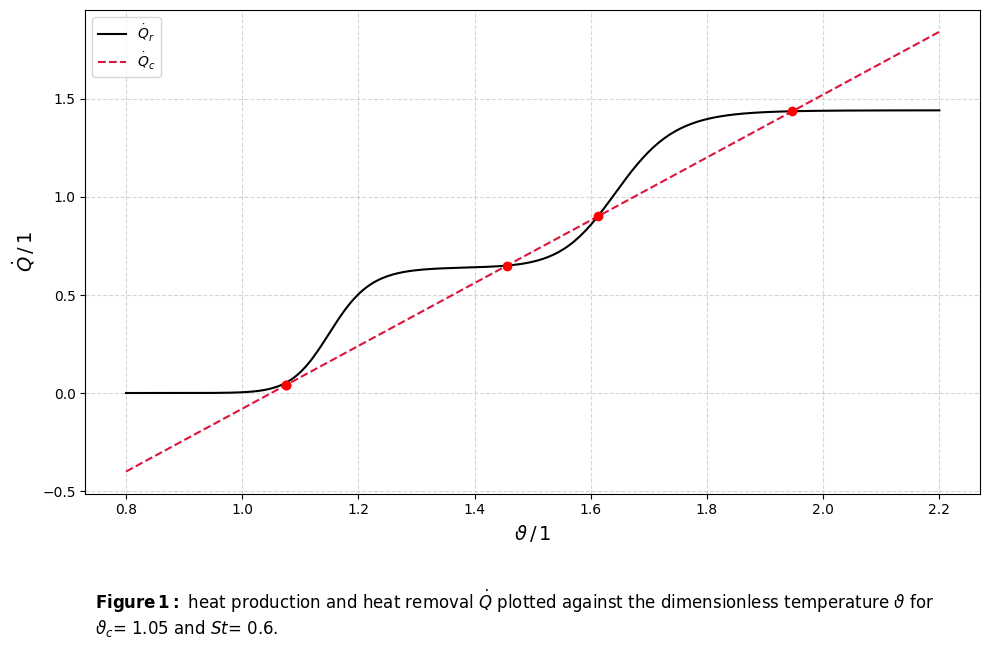

In [8]:
initial_guesses = [                                                  # initial guesses for all operating points
    np.array([0.33, 0.33, 0.34, 0.80]), 
    np.array([0.33, 0.33, 0.34, 1.12]), 
    np.array([0.33, 0.33, 0.34, 1.52]), 
    np.array([0.33, 0.33, 0.34, 1.65]), 
    np.array([0.33, 0.33, 0.34, 2.10]),
]

# --- solve for initially given theta_c and St number ---
results_thetaC_1 = solve_CSTR(theta_c[2], St[2], Da[0], initial_guesses)  # solve for theta_c[2] = 1.05, St[1] = 0.6, Da[0] = 0.006

# --- one single plot for one theta_c and St ---
plt.figure(figsize=(10,6))
color = ['steelblue', 'darkorange', 'green', 'crimson', 'deeppink', 'darkmagenta', 'black']     # define color palette
plt.plot(theta, Q_r, 'k-', label=r"$\dot{Q}_{r}$")                   # plot Q_r over theta
plt.plot(theta, Q_c[2, 2, : ], '--', color=color[3], label=fr'$\dot{{Q}}_c$')  # plot Q_c over theta (Q_c[2, 2, : ] -> [St[], theta_c[], theta])
for sol in results_thetaC_1:                                         # loop over scenarios and plot intersection points
    plt.plot(sol[-1], (1 + St[2]) * (sol[-1] - theta_c[2]), f'{'r'}o')

plt.xlabel(r"$\vartheta\,/\,1$", fontsize=14)                        # set x label
plt.ylabel(r"$\dot{Q}\,/\,1$", fontsize=14)                          # set y label
plt.grid(True, linestyle='--', alpha=0.5)                            # add grid
plt.legend(loc='best', frameon=True)                                 # add legend
plt.figtext(0.1, -0.06,                                              # add caption
            r"$\mathbf{Figure\,1:}$ heat production and heat removal $\dot{Q}$ "
            r"plotted against the dimensionless temperature $\vartheta$ for "
            r" $\vartheta_c $= 1.05 and $St $= 0.6.",
            wrap=True, horizontalalignment="left", fontsize=12)
plt.tight_layout(rect=[0, 0.06, 1, 1])                               # adjust layout to fit caption
plt.savefig("A3_Qc_Qr_2.png", dpi=300, bbox_inches='tight')          # save figure
plt.show()

Figure 1 shows a doble "S" curve, which corresponds to the heat produced by two successive exothermic reactions. Furthermore, the appearance of multiple steady states (as evidenced by multiple intersections) is consistant with known CSTR behaviour for exothermic reactions as presented in [5]. The use of different initial guesses in the root solver confirmed the models capability to capture all physically meaningful steady states.  

To verify the found stationary solutions, the residuals of the numerical solvers (the calculated values for $f_1$, $f_2$, $f_3$ and $\vartheta$) are reimplemented into the function `CSTR_balance()`. For a correct solution, the residuals then calculated are expected to be near zero.

In [9]:
# calculate stationary solution for basic scenario
sol = root(CSTR_balance, initial_guesses[0], args=(theta_c[2], St[1], Da[0]), method = 'lm') 

if sol.success:                                                       # test for convergence
    f_ss = sol.x
    print("✅ Found stationary solution:", f_ss)

    residuals = CSTR_balance(f_ss, theta_c[2], St[1], Da[0])          # calculate residuals using found stationary solution 
    print("   Balance residuals:", residuals)

    if np.all(np.abs(residuals) < 1e-6):                              # test for small residuals
        print("✅ Validation successful: All residuals < 1e-6")
    else:
        print("⚠️ Caution: Some residuals > 1e-6 -> bad convergence or numerical errors")
else:
    print("❌ No successful convergence for stationary solution.") 

✅ Found stationary solution: [9.26387302e-01 7.28994645e-02 1.17990185e-09 1.07164086e+00]
   Balance residuals: [7.13224084e-04 8.45707733e-09 3.16458062e-16 1.52764220e-02]
⚠️ Caution: Some residuals > 1e-6 -> bad convergence or numerical errors


The computed residuals for well-converged cases are in the range of 10$^{-9}$ to 10$^{-6}$, indicating excellent numerical agreement with the mass and energy balance equations. Additionally, it was observed that the solver converged to different steady states depending on the initial guess. That behaviour shows a physically plausible multistability in the exothermic system, where the coupling between reaction kinetics and heat removal can lead to multiple equilibrium state, as mentioned before. In some cases, notably at lower initial guesses for the temperature, larger residuals were observed (e.g. up to 10$^{-2}$ in the energy balance). These results highlight the sensitivity of the system to initial conditions and underscore the need for careful selection of the starting values wen exploring multiple operation points. 
  
This combined approach of visual and numerical verification proved effective in checking the correct behavior of the model, especially in detecting multiple operation points and ensuring thermodynamic plausability.

## 3 Investigation of the CSTR behaviour in steady-state
In this section, the steady-state behaviour of an continuous stirred-tank reactor with consecutive exothermic reactions is analyzed. The goal is to determine under which operation conditions the reactor reaches thermal and chemical equilibrium, and whether multiple steady states occur.  
The core of this analysis is the solution of the mass and energy balace equations under stationary conditions. The resulting system of nonlinear equations defined in section 2.2 is solved numerically using initial guesses at several operation points. For each solution, the residual fractions and temperature at steady state are obtained.  
To assess thermal stability, the dimensionless heat production and removal rates are plottet as functions of the reactor temperature. The steady states correspond to the intersection points of the two curves. At such a point, the heat generated by the reactions equals the heat removed via cooling. The number and position of intersection points reveal important characteristics of the reactor system, such as the existance of multiple steady states, thermal stability or instability and the sensitivity to the operating parameters. 

### 3.1 Variation of the effective cooling temperature
The following code section analyzes the influence of the cooling system on the reactors thermal behaviour by varying the dimensionless cooling temperature $\vartheta_c$ while keeping the Stanton number constant. Three different values of $\vartheta_c$ are considered. For each case, the heat removal curve $\dot{Q}_{c}(\vartheta)$ and the heat production curve $\dot{Q}_{r}(\vartheta)$ are plotted. Their intersections correspond to possible steady-state operation points of the system. 

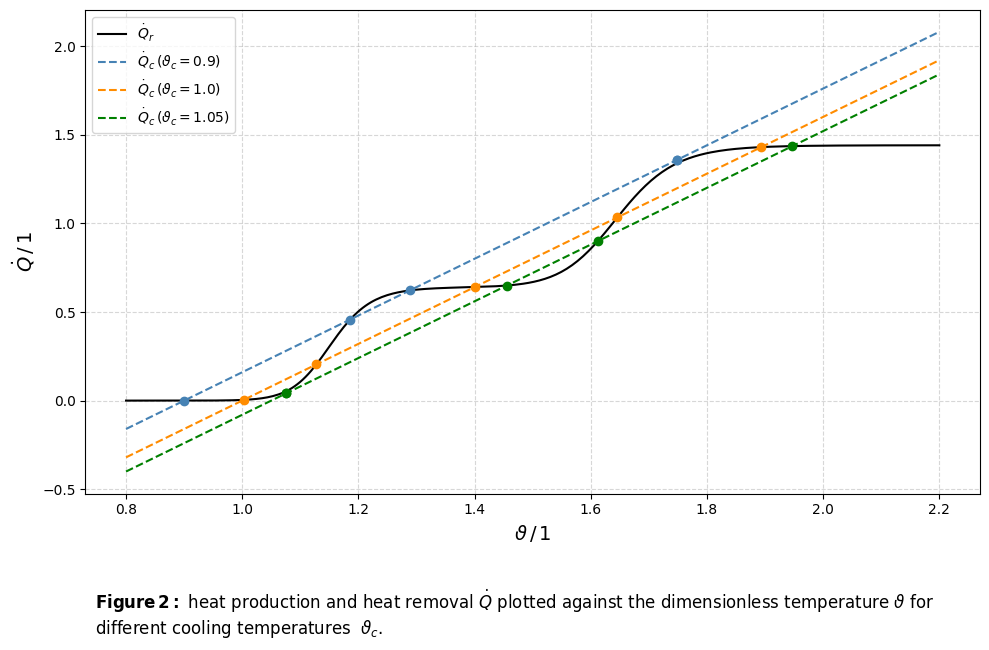

In [10]:
# --- solve for multiple theta_c's (St constant) ---
results_thetaC_0 = solve_CSTR(theta_c[0], St[2], Da[0], initial_guesses)     # solve for theta_c[0]
results_thetaC_1 = solve_CSTR(theta_c[1], St[2], Da[0], initial_guesses)     # solve for theta_c[1]
results_thetaC_2 = solve_CSTR(theta_c[2], St[2], Da[0], initial_guesses)     # solve for theta_c[2]

# --- one single plot for multiple cooling temperatures ---
plt.figure(figsize=(10,6))
plt.plot(theta, Q_r, 'k-', label=r"$\dot{Q}_{r}$")                   # plot Q_r over theta

for i, (theta_c_val, results, label) in enumerate([                  # loop and retrieve theta_c's, results and plotting information using enumerate
    (theta_c[0], results_thetaC_0, fr"$\dot{{Q}}_c\,(\vartheta_c={theta_c[0]}$)"),
    (theta_c[1], results_thetaC_1, fr"$\dot{{Q}}_c\,(\vartheta_c={theta_c[1]}$)"),
    (theta_c[2], results_thetaC_2, fr"$\dot{{Q}}_c\,(\vartheta_c={theta_c[2]}$)")
]):
    plt.plot(theta, Q_c[2, i, : ], '--', color=color[i], label=label)  # plot Q_c over theta (i used to loop through results for different theta_c's: Q_c[St, theta_c's, thetas]) 
    
    for sol in results:                                              # loop over scenarios and plot intersection points
        plt.plot(sol[-1], (1 + St[2]) * (sol[-1] - theta_c_val), marker='o', color=color[i])

plt.xlabel(r"$\vartheta\,/\,1$", fontsize=14)                        # set x label
plt.ylabel(r"$\dot{Q}\,/\,1$", fontsize=14)                          # set y label
plt.grid(True, linestyle='--', alpha=0.5)                            # add grid
plt.legend(loc='best', frameon=True)                                 # add legend
plt.figtext(0.1, -0.06,                                              # add caption
            r"$\mathbf{Figure\,2:}$ heat production and heat removal $\dot{Q}$ "
            r"plotted against the dimensionless temperature $\vartheta$ for different cooling temperatures "
            r" $\vartheta_c$.",
            wrap=True, horizontalalignment="left", fontsize=12)
plt.tight_layout(rect=[0, 0.06, 1, 1])                               # adjust layout to fit caption
plt.savefig("A3_Qc_Qr_2.png", dpi=300, bbox_inches='tight')          # save figure
plt.show()

The plots reveal, that for each $\vartheta_c$ multiple steady states exist. Among these, one or more are thermally stable, whole others are unstable or metastable. Stability can be inferred from the slope behaviour. A steady-state point is stable if to the left of the point $\dot{Q}_{r} > \dot{Q}_{c}$ and to the right $\dot{Q}_{r} < \dot{Q}_{c}$. This corresponds to negative feedback as a temperature increase leads to higher cooling than heating, driving the system to equilibrium. In contrast to that show unstable points positive feedback, where a small pertubation causes the system to diverge from equilibrium.  
Considering this, stable operation points are found for all $\vartheta_c$ in the temperature region between $\vartheta \approx 1.3$ and $1.45$. Stable points are also observed at the very high (metastable for $\vartheta_c =0.9$) and low (metastable for $\vartheta_c =1.05$) ends of the temperature axis. 

### 3.2 Variation of the heat transfer
In this section, the influence of the Stanton number $St$ on the steady-state behavior is analyzed, while the dimensionless cooling temperature is kept constant. The Stanton number characterizes the intensity of heat removal and is defined as the ration of the heat transfer rate to the thermal capacity flow. The following code cell implementing this study uses the same code structure as before, now feeding the `solve_CSTR()` function with different Stanton values.  
In addition, the isothermal ($St \rightarrow \infty$, note: 1e10 used in plot) and adiabatic ($St = 0$) limiting cases are shown for comparison:

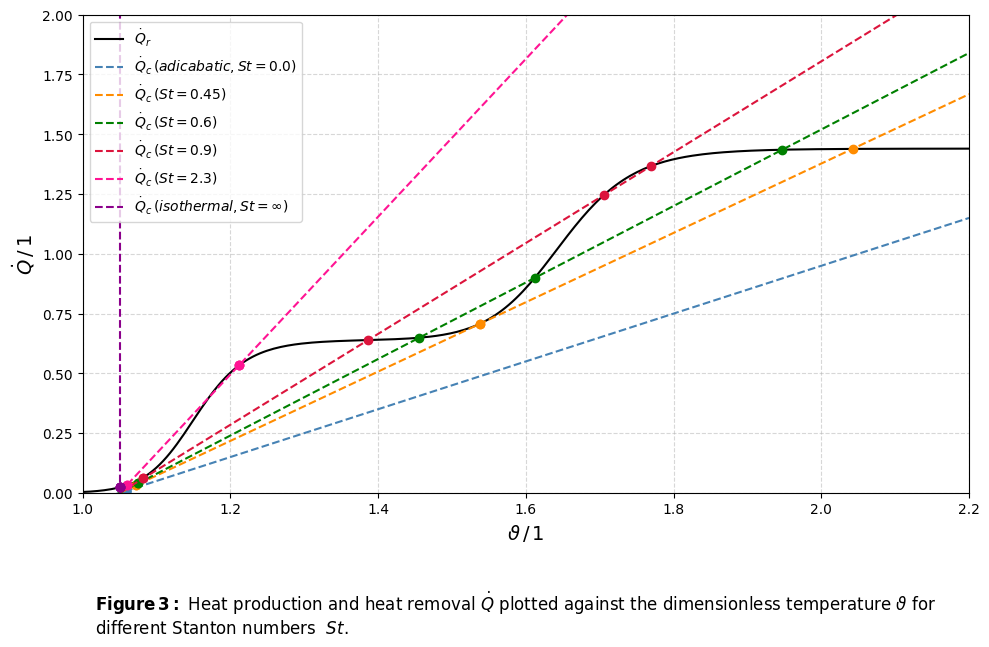

In [11]:
# --- solve for multiple Stanton numbers (theta_c constant) ---
results_Stanton_0 = solve_CSTR(theta_c[2], St[0], Da[0], initial_guesses)     # solve for St[0], adiabatic
results_Stanton_1 = solve_CSTR(theta_c[2], St[1], Da[0], initial_guesses)     # solve for St[1]
results_Stanton_2 = solve_CSTR(theta_c[2], St[2], Da[0], initial_guesses)     # solve for St[2]
results_Stanton_3 = solve_CSTR(theta_c[2], St[3], Da[0], initial_guesses)     # solve for St[3]
results_Stanton_4 = solve_CSTR(theta_c[2], St[4], Da[0], initial_guesses)     # solve for St[4]
results_Stanton_5 = solve_CSTR(theta_c[2], St[5], Da[0], initial_guesses)     # solve for St[5], isothermic

# --- one single plot for multiple Stanton numbers ---
plt.figure(figsize=(10,6))
plt.plot(theta, Q_r, 'k-', label=r"$\dot{Q}_{r}$")                   # plot Q_r over theta

for i, (St_val, results, label) in enumerate([                       # loop and retrieve St's, results and plotting information using enumerate
    (St[0], results_Stanton_0, fr"$\dot{{Q}}_c\,(adicabatic,  St={St[0]}$)"),
    (St[1], results_Stanton_1, fr"$\dot{{Q}}_c\,(St={St[1]}$)"),
    (St[2], results_Stanton_2, fr"$\dot{{Q}}_c\,(St={St[2]}$)"),
    (St[3], results_Stanton_3, fr"$\dot{{Q}}_c\,(St={St[3]}$)"),
    (St[4], results_Stanton_4, fr"$\dot{{Q}}_c\,(St={St[4]}$)"),
    (St[5], results_Stanton_5, fr"$\dot{{Q}}_c\,(isothermal,St=\infty$)")
]):
    plt.plot(theta, Q_c[i, 2, : ], '--', color=color[i], label=label)  # plot Q_c over theta (i used to loop through results for different St numbers: Q_c[St's, theta_c, thetas])
    
    for sol in results:                                              # loop over scenarios and plot intersection points
        plt.plot(sol[-1], (1 + St_val) * (sol[-1] - theta_c[2]), marker='o', color=color[i])

plt.xlabel(r"$\vartheta\,/\,1$", fontsize=14)                        # set x label
plt.ylabel(r"$\dot{Q}\,/\,1$", fontsize=14)                          # set y label
plt.xlim(1, 2.2)                                                     # set x limit
plt.ylim(0, 2)                                                       # set y limit
plt.grid(True, linestyle='--', alpha=0.5)                            # add grid
plt.legend(loc='best', frameon=True)                                 # add legend
plt.figtext(0.1, -0.06,                                              # add caption
            r"$\mathbf{Figure\,3:}$ Heat production and heat removal $\dot{Q}$ "
            r"plotted against the dimensionless temperature $\vartheta$ for different Stanton numbers "
            r" $St$.",
            wrap=True, horizontalalignment="left", fontsize=12)
plt.tight_layout(rect=[0, 0.06, 1, 1])                               # adjust layout to fit caption
plt.savefig("A3_Qc_Qr_3.png", dpi=300, bbox_inches='tight')          # save figure
plt.show()

The results show in the adiabatic case, no intersection occurs, except at $\dot{Q} = 0$, while the isothermal case results in a fixed-temperature scenario with an intersection in the same region. For low $St$ values the systems low heat removal capacity leads to the possibility of thermal runaway reactions, as the intersection points at lower reactor temperatures are metastable and the only stable point is found at the higher end of the temperature axis. In contrast, higher Stanton numbers ($St = 0.6$ and $0.8$) shows multiple possibly stable intersections, one at $\vartheta \approx 1.4$ and $1.45$ and one at the higher end. At the lower end for each $St$ value  common metastable points are found at $\dot{Q} = 0$ and $\vartheta = 1.05$. This point is the zero-crossing of the cooling curve, occurring where the reactor temperature equals the inlet (cooling) temperature. Although this condition satisfies the heat balance mathematically, itmost likely is thermally unstable, as small deviations from this temperature lead to a positive net heat flow, driving the system away from equilibrium. This raises the question of how the reactor dynamically responds to small perturbations. Therefore, in chapter 4, the dynamic behavior of the CSTR is investigated.  

### 3.3 Variation of the Damköhler number
To study the influence of reaction kinetics on the thermal steady-state behavior of the reactor, the Damköhler number $Da$ is varied while keeping the Stanton number and the effective cooling temperature constant. This approach allows to analyze how different reaction rates affects the number and location of possiple steady-state intersections. For eaach $Da$, the temperature-dependent reaction rates are recalculated in the second code cell of chapter 2.2 and used to determine the corresponding profile. The cooling curve is plotted only once, as it is independent of $Da$.

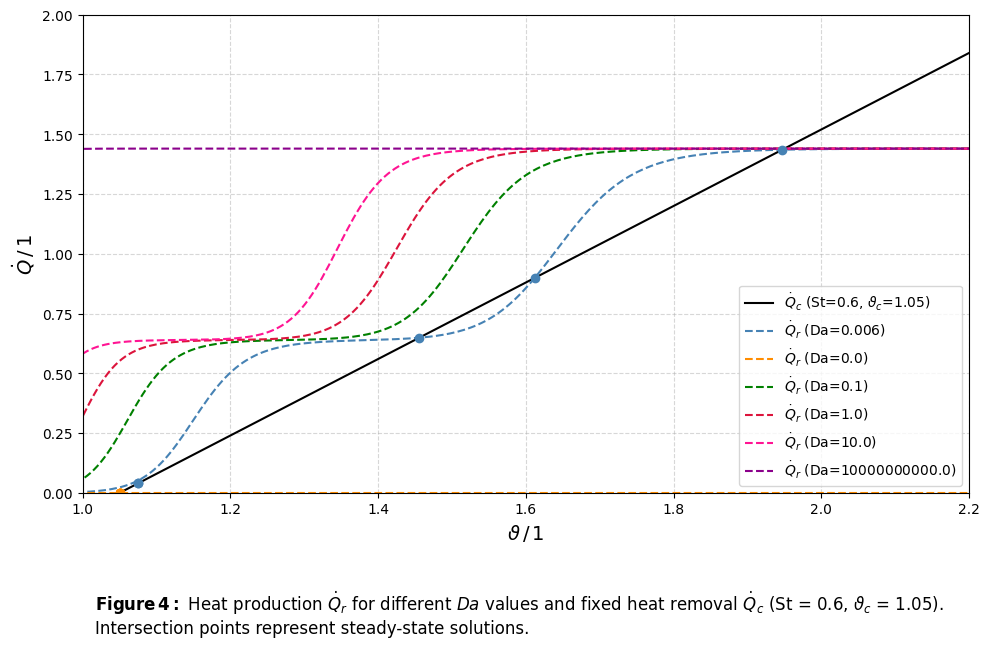

In [12]:
results_Da = []                                                      # prepare empty results array
for Da_val in Da:                                                    # calculate stationary solutions for all Da
    results_Da.append(solve_CSTR(theta_c[2], St[2], Da_val, initial_guesses))

plt.figure(figsize=(10, 6))                                          # prepare figure and plot

Q_c_line = (1 + St[2]) * (theta - theta_c[2])                        # calculate single Q_c line (basic scenario)
plt.plot(theta, Q_c_line, 'k-', label=fr"$\dot{{Q}}_c$ (St={St[2]}, $\vartheta_c$={theta_c[2]})") # plot Q_c for given values

for i, Da_val in enumerate(Da):                                      # loop over results and plot Q_r graphs
    plt.plot(theta, Q_r_Da[i, :], '--', color=color[i], label=fr"$\dot{{Q}}_r$ (Da={Da_val})")
    
for sol in results_Da[0]:                                            # loop over solution array
    Q_c_eq = (1 + St[2]) * (sol[-1] - theta_c[2])                    # calculate Q_c values for intersection points 
    plt.plot(sol[-1], Q_c_eq, marker='o', color=color[0])            # plot intersection points
for sol in results_Da[1]:                                            # loop over solution array
    Q_c_eq = (1 + St[2]) * (sol[-1] - theta_c[2])                    # calculate Q_c values for intersection points 
    plt.plot(sol[-1], Q_c_eq, marker='o', color=color[1])            # plot intersection points


plt.xlabel(r"$\vartheta\,/\,1$", fontsize=14)
plt.ylabel(r"$\dot{Q}\,/\,1$", fontsize=14)
plt.xlim(1, 2.2)
plt.ylim(0, 2)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='best', frameon=True)
plt.figtext(0.1, -0.06,
    r"$\mathbf{Figure\,4:}$ Heat production $\dot{Q}_r$ for different $Da$ values and fixed heat removal $\dot{Q}_c$ "
    fr"(St = {St[2]}, $\vartheta_c$ = {theta_c[2]}). Intersection points represent steady-state solutions.",
    wrap=True, horizontalalignment="left", fontsize=12)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig("A3_Qc_Qr_Da_with_roots.png", dpi=300, bbox_inches='tight')
plt.show()


The results show for low Damköhler numbers ($Da = 0$), the reaction rate becomes negligible, and the heat generation curve flattens. In this limit, the system behaves almost inert, and no heat is generated. A single intersection point with the cooling curve exists at very low temperatures, corresponding to a practically unreactive, cold state. For high values ($Da \rightarrow \infty$, note: 1e10 used to plot), the heat production curve $\dot{Q}_r$ becomes linear and the system reaches a thermally dominant regime. In this case, no intersection with the cooling curve occurs, except at very high temperatures, which corresponds to thermal runaway. For intermediate values, such as the base case $Da = 0.006$, multiple intersections are observed, indicating multiple possible steady states. This suggests that the reactor may operate in either a low-temperature or high-temperature state depending on initial conditions and perturbations. To further explore the these phenomena, the next section investigates the dynamic behavior of the reactor.

## 4 Investigation of the dynamic CSTR behavior
Following the identification of multiple steady states in the previous section, the focus now shifts to analyzing how the reactor behaves dynamically when subjected to transiend conditions. The aim is to examine stability, potential ignition behavior, and the occurance of multiple steady states, thermal runaway or oscillations under differend operating scenarios.  
For this purpose, the dynamic mass and energy balances are implemented in the function `dyn_CSTR_balance()`, which computes the time derivatives of the system state (component concentrations and temperature). These equations are solved using the time integrator `solve_ivp` within the function `simulate_CSTR_dynamics`, which allows parameter studies over various operating conditions. 

Reaction specific parameters such as  $\beta_j$ and $\gamma_j$ will be kept constant as explained earlier, since in this chapter we expect the underlying reactions as given and rather focus our studies on different operation conditions that might be chosen. The following three operating parameters are varied systematically to assess their influence on the reactor dynamics:
1. Stanton number ($St$): Represents the cooling intensity and controls how effectively temperature deviations are dampened.
2.  Damköhler number ($Da$): Describes the ratio between the characteristic reaction rate and the convective flow rate, determining how rapidly heat and mass are generated.
3.   Inlet temperature ($\vartheta_{in}$): Sets the initial thermal state of the reactor and strongly influences whether the system approaches a low- or high-temperature steady state and whether transient overshoots or runaway reactions occur.
 
In the following subsections, the influence of each parameter is analyzed individually to identify stable, metastable and unstable operating regimes and to explore the systems responses. 

In [13]:
def dyn_CSTR_balance(time, f, St_val, Da_val, theta_c_val):
    ''' computes residuals of mass and heat balances for a unsteady-state CSTR with a following reaction
    Parameters: - time:
                - f: array_like Vector of dimensionless outlet molar fractions [f1, f2, f3, theta]
                - St_val: Stanton number (dimensionless, float)
                - Da_val: Damköhler number (dimensionless, float)
                - theta_c_val: effective cooling temperature (dimensionless, float)
    Returns:    - dfdt: array with residuals of following balance equations: [mass A1, mass A2, mass A3, heat]
    '''
    dfdt = np.empty((4))                                             # empty array for residual fractions and temperature
    w = rxn_w(f, gamma[0], gamma)                                    # call the function for reaction rate

    # Mass balance for components A1, A2, A3
    dfdt[0] = f_in[0] - f[0] - Da_val * w[0]                         # unsteady state mass balance A1
    dfdt[1] = f_in[1] - f[1] + Da_val * (w[0] - w[1])                # unsteady state mass balance A2
    dfdt[2] = f_in[2] - f[2] + Da_val * w[1]                         # unsteady state mass balance A3
    
    # Heat balance
    dfdt[3] = (1 + St_val) * (theta_c_val - f[-1]) + Da_val * (beta[0] * w[0] + beta[1] * w[1])

    return dfdt

In [14]:
def simulate_CSTR_dynamics(St_list, Da_list, theta_in_list, f_init=None):
    ''' simulates the dynamic behavior of a CSTR for varying operating parameters.
    Parameters: - St_list: list or array of stanton numbers to evaluate
                - Da_list: list or array of Damköhler numbers to evaluate
                - theta_in_list: list or array of inlet temperatures (dimensionless) corresponding to each simulation
                - f_init: optional array defining the initial state vector [f1, f2, f3, theta_in]. If None, will be set to [f_base, theta_in_list[0]].
    Returns:    - results: list containing solution objects (time profiles) for each simulation case.
                           each dict includes: {'St': value, 'Da': value, 'theta_in': value, 'solution': solve_ivp result}
    '''
    if f_init is None:
        f_init = np.append(f_base, theta_in_list[0])                  # default initial conditions 

    fig, axs = plt.subplots(1, 4, figsize=(22, 5))                    # prepare plot
    labels   = [r"$f_1$", r"$f_2$", r"$f_3$", r"$\vartheta$"]         # define labels for subplots

    for St in St_list:                                                # loop over St_numbers
        for Da in Da_list:                                            # loop over Da_numbers
            for theta_c in theta_in_list:                             # loop over theta_ins
                # call solver using lambda to freeze St_val, Da_val and theta_c_val, since solve_ivp expects only three arguments
                sol = solve_ivp(lambda t, f: dyn_CSTR_balance(t, f, St, Da, theta_c), t_span, f_init, method='BDF', dense_output=True, rtol=1e-6, atol=1e-9)
    # Plot results
                for i in range(4):                                     # plot results in three subplots for f1, f2, f3
                    axs[i].plot(sol.t, sol.y[i], label=fr"$St={St}$, $Da={Da}$, $\vartheta_\mathrm{{in}}={theta_c}$")
    for i in range(4):
        axs[i].set_xlabel(r"$\theta\,/\,1$")                          # set x label
        axs[i].set_ylabel(labels[i])                                  # set y labels
        axs[i].set_title(f"{labels[i]} over time")                    # set titles
        axs[i].legend(loc="best", fontsize = 9)                       # add legend
        axs[i].grid(True, linestyle='--', alpha=0.3)                  # add grid
    plt.tight_layout()

### 4.1 Verification of the dynamic CSTR model
To validate the correctness and the physical realism of the implemented dynamic model of the continuously stirred-tank reactor, a systematic approach is used. The goal is to demonstrate that the model behaves consistently with the expected reactor dynamics, particularly in reaching steady-state behaviour. Therefore the system is simulated under specific operating conditions, which are considered the base scenario:
- Stanton number: $St = 0.6$
- Cooling temperature: $\vartheta_c = 1.05$
- Damköhler number: $Da = 6\cdot 10^{-3}$  

As initial conditions for the solver no inlet flow ($f_1 = f_2 = f_3 = 0$) is defined in order to also observe the start up behaviour of the system. The `f_init` array also consists of the dimensionless temperature of the inlet flow $\vartheta = 1.05$, which for this analysis equals the cooling temperature.


In [15]:
# used parameters for reactor operation are the given ones defined in code cell [2]  
t_span = ([0, 100])                                                  # define time period for evaluation, dimensionless
f_init = np.array([0, 0, 0, theta_c[2]])                             # define initial conditions: no inlet in the beginning, therefore start-up observed

# call initial value problem solver 
CSTR_sol_dyn = solve_ivp(dyn_CSTR_balance, t_span, f_init, method='Radau', args=(St[1], Da[0],theta_c[2]), max_step=0.01, rtol=1e-6, atol=1e-9, dense_output=True, vectorized=False)

# print status of solver
print(fr"{CSTR_sol_dyn.message} (Interval: 0 ... {CSTR_sol_dyn.t[-1]}, Status: {CSTR_sol_dyn.status})")

The solver successfully reached the end of the integration interval. (Interval: 0 ... 100.0, Status: 0)


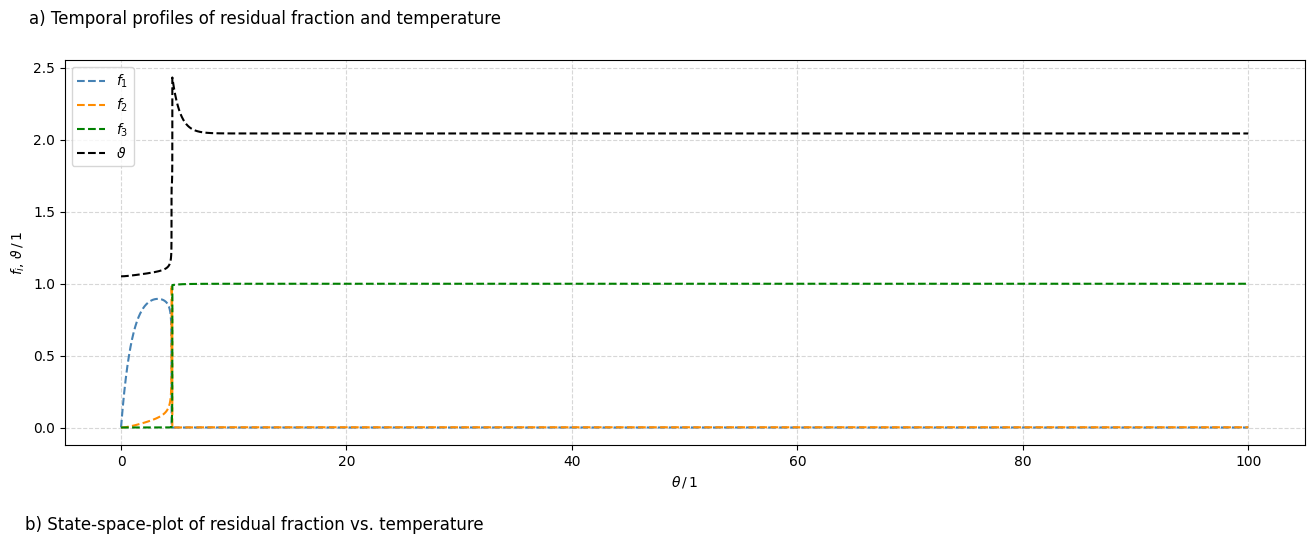

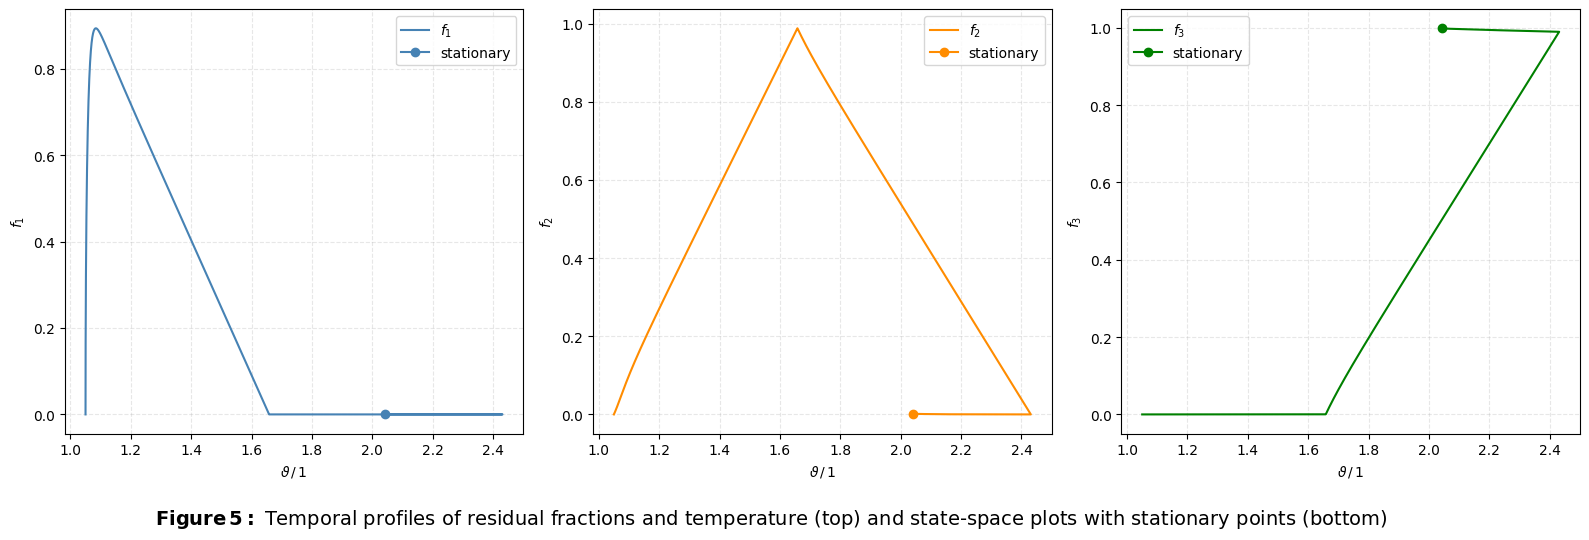

In [16]:
def plot_fi_theta(): # define function to hold plot of the temporal profiles of residual fraction and temperature
    plt.figure(figsize=(16, 5))
    plt.plot(CSTR_sol_dyn.t, CSTR_sol_dyn.y[0,:], '--', color=color[0], label="$f_1$")  # residual fraction A1
    plt.plot(CSTR_sol_dyn.t, CSTR_sol_dyn.y[1,:], '--', color=color[1], label="$f_2$")  # residual fraction A2
    plt.plot(CSTR_sol_dyn.t, CSTR_sol_dyn.y[2,:], '--', color=color[2], label="$f_3$")  # residual fraction A3
    plt.plot(CSTR_sol_dyn.t, CSTR_sol_dyn.y[-1,:],'--', color=color[6], label="$\\vartheta$") # temperature
    plt.xlabel(r"$\theta\,/\,1$")
    plt.ylabel(r"$f_i$, $\vartheta\,/\,1$")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='best')
    #plt.figtext(0.1, -0.06,r"$\mathbf{Figure\,4:}$ Temporal profiles of residual fractions and temperature",wrap=True, horizontalalignment="left", fontsize=10) # add caption
    plt.suptitle('a) Temporal profiles of residual fraction and temperature', x=0.25, fontsize=12) # title for upper plot
    plt.figtext(0.1, -0.06,'b) State-space-plot of residual fraction vs. temperature', horizontalalignment="left", fontsize=12)   # title for lower plot
    plt.show
    
def plot_statespace(): # define function to hold state-space-plot of residual fraction vs. temperature
     # stationary end point (last value of solution)
    theta_ss = CSTR_sol_dyn.y[3, -1]                                     # temperature
    f_ss     = CSTR_sol_dyn.y[0:3, -1]                                   # f1, f2, f3
    
    fig, axs = plt.subplots(1, 3, figsize=(16, 5))
    labels = [r"$f_1$", r"$f_2$", r"$f_3$"]
    for i in range(3):
        axs[i].plot(CSTR_sol_dyn.y[3, :], CSTR_sol_dyn.y[i, :], color=color[i], label=labels[i])
        axs[i].plot(theta_ss, f_ss[i], marker='o', color=color[i], label="stationary")
        axs[i].set_xlabel(r"$\vartheta\,/\,1$")
        axs[i].set_ylabel(labels[i])
        axs[i].grid(True, linestyle='--', alpha=0.3)
        axs[i].legend(loc='best')
        #axs[i].set_title(f"{labels[i]} vs. $\\vartheta$")
    plt.tight_layout()

plot_fi_theta()                                                           # call functions to plot f_i, theta vs. dimensionless time and state-space diagrams 
plot_statespace()
plt.figtext(0.1, -0.06,r"$\mathbf{Figure\,5:}$ Temporal profiles of residual fractions and temperature (top) and state-space plots with stationary points (bottom)",wrap=True, horizontalalignment="left", fontsize=14) # add caption
plt.show()                                                                # show plot for basic conditions

From the upper plot (a) of figure 5, it is clearly visible that the system does not remain near the initial condition but undergoes a thermal runaway, stabilizing at higher temperature of approximately $\vartheta \approx 1.95$ and a nearly complete conversion to product $A_3$ ($f_3 \approx 0.99$). This matches the topmost stationary point found in the steady-state analysis. The reaction is highly exothermic, and the cooling is insufficient to maintain an intermediate steady state.  
The state-space plots (b) show smooth trajectories converging to a unique attractor. Each path highlits the interdependence of conversion and reactor temperature. No oscillations or metastable behavior is observed, further confirming that this operation point is a stable attractor.  

To ensure that the final point from the dynamic simulation indeed satisfies the original system of balance equations, we re-insert the final values into the balance equations using the `dyn_CSTR_balance()` function. The residuals of the mass and energy balances were evaluated at the final time point $\theta = 100$:

In [17]:
res_dyn = dyn_CSTR_balance(CSTR_sol_dyn.t[-1], CSTR_sol_dyn.y[:, -1], 0.6, 6.e-3, 1.05)
print("Balance residuals:", res_dyn)

Balance residuals: [-1.11022302e-16  1.09721260e-16  5.32907052e-15 -1.48835203e-01]


The resulting residuals were found to be very small ($\approx 10^{-14}$), confirming that the dynamic endpoint satisfies the mass and heat balance equations to high numerical accuracy. This confirms first of all that the implementation of the dynamic model (ODE system) is correct and consistent with the balance equations. Secondly it confirms that the numerical solver reached a true steady state, corresponding exactly to the topmost stationary point identified previously.

### 4.2 Variation of the Stanton number
In this section, it is investigated how varying the Stanton number $St$ affects the dynamic response of the CSTR system. As the Stanton number quantifies the intensity of heat removal in the reactor, it characterizes how efficiently the temperature of the reactor is controlled via cooling and directly influences the thermal stability and reaction dynamics. Because the reaction rate is temperature-sensitive (Arrhenius-type kinetics), the Stanton number thus critically influences how fast and how far the temperature and with that the concentrations evolve over time.  
To examine this behavior, the system is simulated dynamically for a set of different $St$ values, while the other parameters are kept constant. The dynamic species concentrations (plotted as $f_i$) and temperature ($\vartheta$) are recorded as functions over time using `simulate_CSTR_dynamics()` defined above:

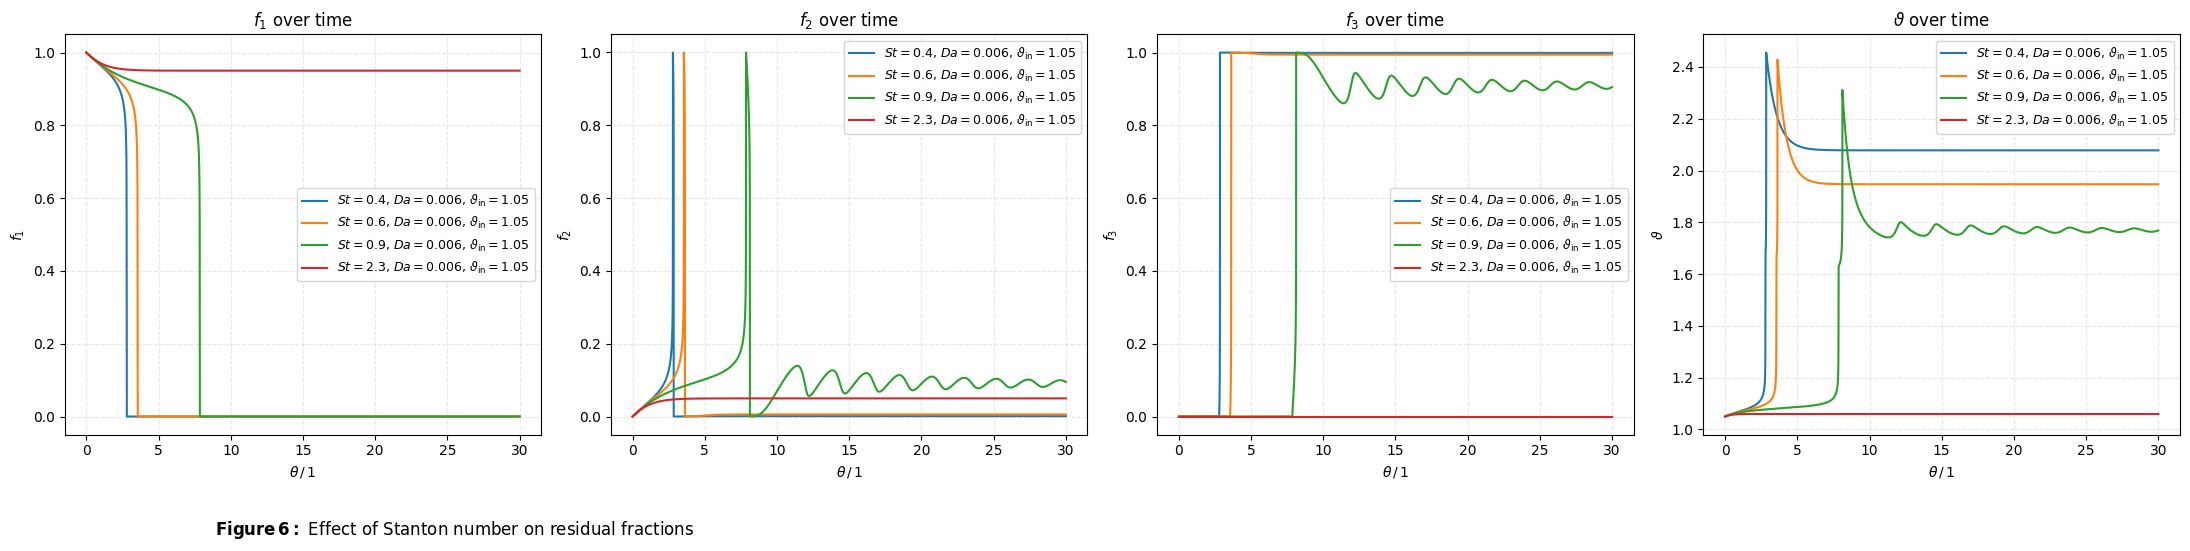

In [18]:
t_span = ([0, 30])                                                   # define new time period for evaluation, dimensionless

simulate_CSTR_dynamics(St_list=[0.4, 0.6, 0.9, 2.3], Da_list=[6e-3], theta_in_list=[1.05])  # call simulation function for varied St
plt.figtext(0.1, -0.08, r"$\mathbf{Figure\,6:}$ Effect of Stanton number on residual fractions", wrap=True, ha='left', fontsize=12)
plt.show()                                                           # add caption and show plot

The simulation results clearly demonstrate the significant effect of the Stanton number on the dynamics of the CSTR.  
For low Stanton numbers (e.g. $St = 0.4$), the heat removal is weak and the temperature rises significantly due to the exothermic nature of the reactions. As a result, the system reaches a high-temperature steady state at $\vartheta \approx 2.1$), corresponding to the upper stable branch identified in the steady-state diagram. In this regime, all of the initial reactant $A_1$ is consumed, and the final product $A_3$ is fully formed following a transient accumulation of the intermediate $A_2$.  
For high Stanton numbers (e.g. $St = 2.3$), the system remains close to its initial temperature ($\vartheta \approx \vartheta_\text{in} = 1.05$), and the dynamics are effectively suppressed. Due to the limited temperature increase, the reaction barely proceeds ($f_1$ remains around 0.9, while $f_3$ stays near zero).  
At an intermediate Stanton number of 0.9, the system exhibits damped oscillations. The temperature overshoots and then settles near $\vartheta \approx 1.8$ with $f_1$ being completely consumed and $f_3$ setteling around 0.9.  
  
To investigate the oscillatory behavior observed, additional plots were generated. These include both the temporal evolution of the residual fractions and the dimensionless temperature, as well as corresponding state-space diagrams. This detailed visualization allows a clearer assessment of the systems dynamics, such as the amplitude and dampening of the oscillations:

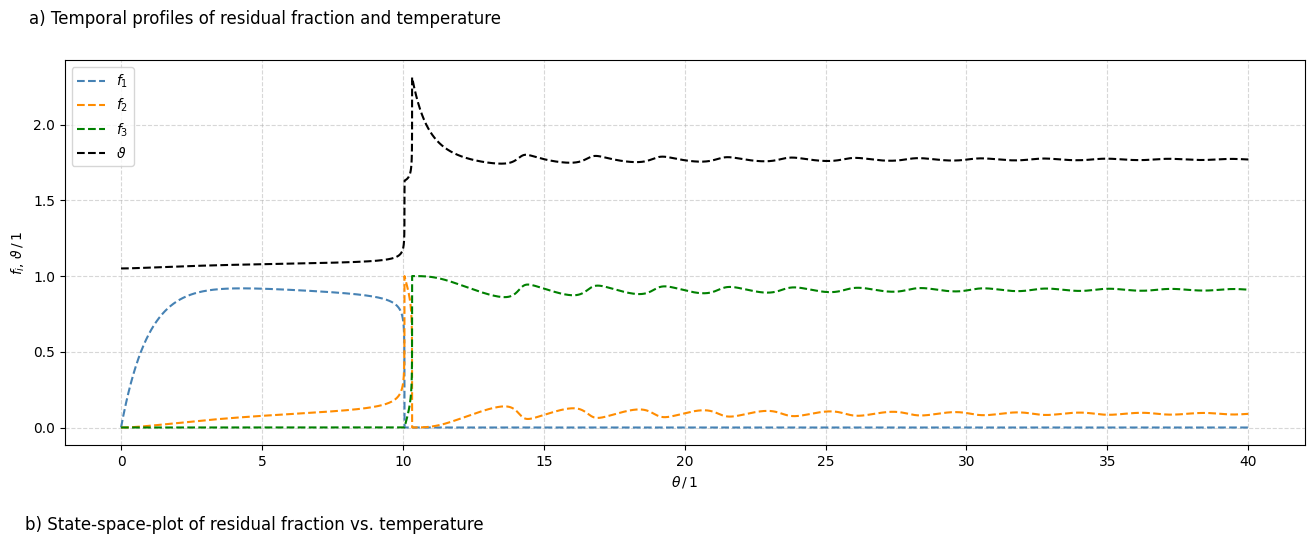

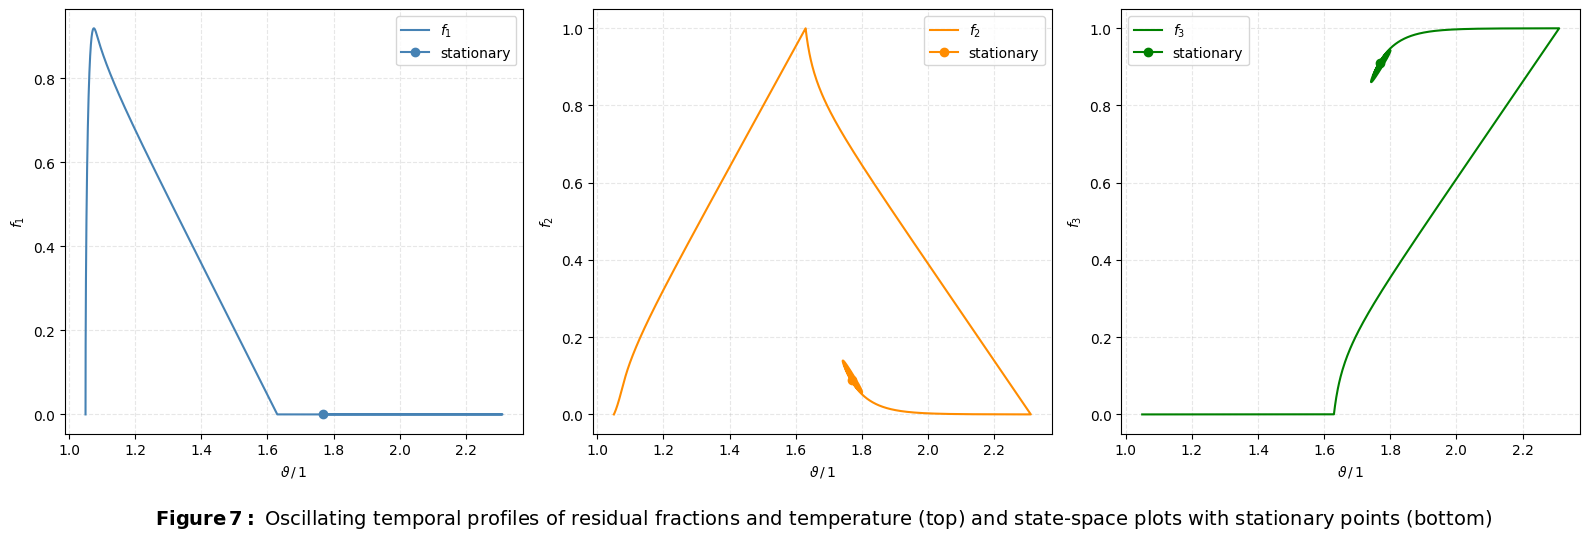

In [19]:
t_span = ([0, 40])                                                   # define new time period for evaluation, dimensionless
# call initial value problem solver for oscillating St value
CSTR_sol_dyn = solve_ivp(dyn_CSTR_balance, t_span, f_init, method='Radau', args=(0.9, Da[0], theta_c[2]), max_step=0.01, rtol=1e-6, atol=1e-9, dense_output=True, vectorized=False)

plot_fi_theta()                                                      # call functions to plot f_i, theta vs. dimensionless time and state-space diagrams 
plot_statespace()
plt.figtext(0.1, -0.06,r"$\mathbf{Figure\,7:}$ Oscillating temporal profiles of residual fractions and temperature (top) and state-space plots with stationary points (bottom)",wrap=True, horizontalalignment="left", fontsize=14) # add caption
plt.show()                                                           # show plot for St = 0.9

The time-domain plots (a) reveal synchronized oscillations of the temperature profile and the residual fractions of the intermediate and final products. These oscillations gradually decay in amplitude, indicating that the system approaches a stable steady state. The reactant $A_1$ is nearly fully consumed from around $\theta \approx 10$ onward.  
The state-space diagrams (b) further illustrate this behavior as the trajectories of $f_2$ and $f_3$ spiral around the steady-state point in a damped circular pattern. This phase-space evolution confirms that the system exhibits a stable focus and reaches the stationary point only asymptotically in the limit of infinite time.

### 4.3 Variation of the Damköhler number
To analyze the impact of reaction kinetics on the dynamic behavior of the CSTR, the Damköhler number is varied. This parameter relates to characteristic reaction rate to the residence time in the reactor and thus reflects the degree of coupling between chemical reaction and flow. The initial conditions and all other parameters are kept constant while observing how changes in $Da$ affect the temporal profiles. As before, the `simulate_CSTR_dynamics()` function is used to solve and depict the equations for the given parameters:

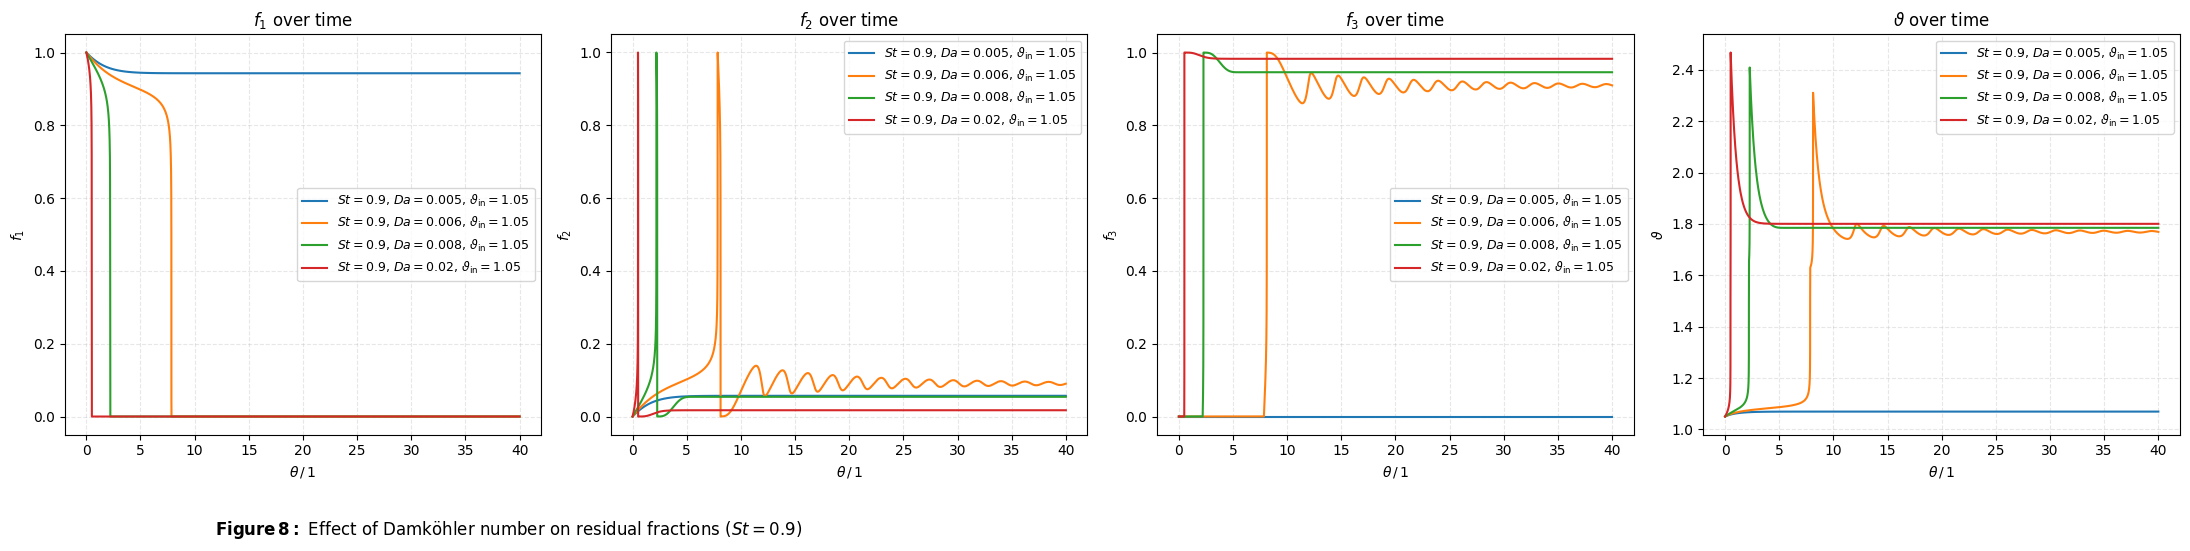

In [20]:
t_span = ([0, 40])                                                   # define new time period for evaluation, dimensionless

simulate_CSTR_dynamics(St_list=[0.9], Da_list=[5e-3, 6e-3, 8e-3, 0.02], theta_in_list=[1.05])  # call simulation function for varied St
plt.figtext(0.1, -0.08, r"$\mathbf{Figure\,8:}$ Effect of Damköhler number on residual fractions ($St=0.9$)", wrap=True, ha='left', fontsize=12)
plt.show()                                                           # add caption and show plot   

Figure 8 shows for low $Da$ numbers (e.g. 0.005) a slow reaction a high residual fraction of $f_1$. Hardly any conversion occurs and the temperature stays low near the inlet temperature.  
At intermediate $Da = 0.006$, the system exhibits damped oscillations, particularly in $f_2$, $f_3$ and $\vartheta$, indicating a delayed but eventually stable conversion.  
For higher $Da$ values (e.g. 0.008 or 0.02), the system responds rapidly, and the final product $A_3$ dominates. The temperature quickly rises and stabilizes around $\vartheta \approx 1.8$ in all cases.   

To complement the previous analysis, an additional case with a higher Stanton number ($St=1.0$) is investigated. All other parameters are held constant:

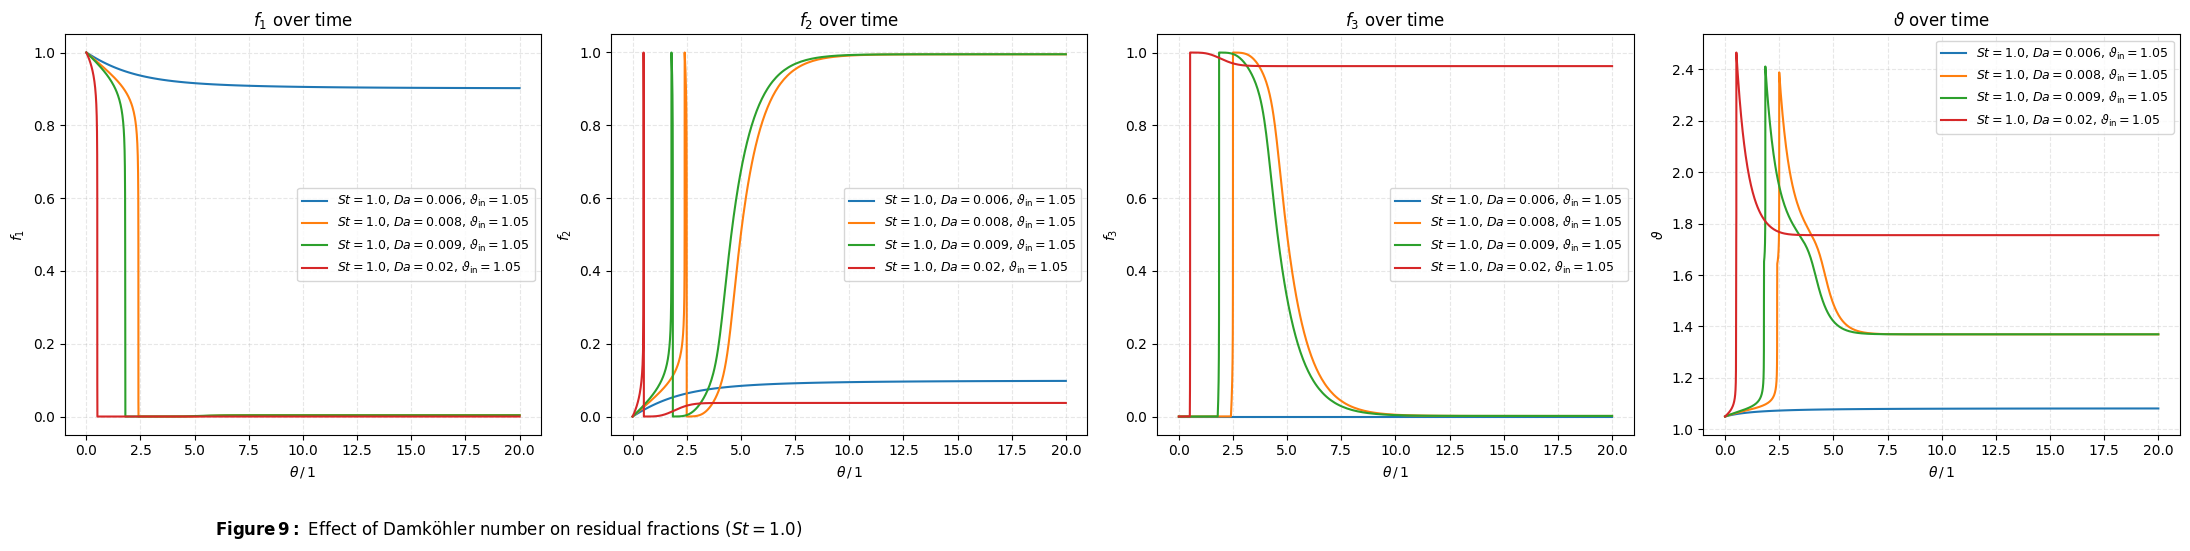

In [21]:
t_span = ([0, 20])                                                   # define new time period for evaluation, dimensionless

simulate_CSTR_dynamics(St_list=[1.0], Da_list=[6e-3, 8e-3, 9e-3, 0.02], theta_in_list=[1.05])  # call simulation function for varied St
plt.figtext(0.1, -0.08, r"$\mathbf{Figure\,9:}$ Effect of Damköhler number on residual fractions ($St=1.0$)", wrap=True, ha='left', fontsize=12)
plt.show()                                                           # add caption and show plot

In this regime, no oscillations are observed. The system approaches a steady state smoothly. The residual fraction of component $A_2$ remains high, while $A_3$ formation is negligible. This outcome reflects limited conversion due to strong cooling, which prevents a significant temperature rise and thus slows down the reaction cascade. Focussing only on the high residuals of $A_2$, from the rightmost plot one can observe a stable temperature at $\vartheta \approx 1.4$ which corresponds to the intermediate steady state found in the static analysis of chapter 3. Based on this analysis, this intermediate point can only be reached through strong cooling, since in earlier plots only stable temperatures around $\theta = 1.8$ have been found, suggesting the thermal runaway otherways.
  
Depending on the desired product, component $A_2$ might be preferred. Therefore the operation parameters resulting in a high residual fraction $f_2$ are suggested ($St=1.0$, $Da=0.006$ and $\vartheta_{in}=1.05$).

### 4.4 Variation of the inlet temperature 
To conclude the operation-parameter based analysis, the influence of the inlet temperature $\vartheta_{in}$ on the reactor behavior is examined using the same functions as earlier described. Since the inlet temperature directly sets the baseline of the cooling medium and defines the minimum achievable reactor temperature, it strongly affects the resulting steady states. In particular, its variation provides insights into how sensitive the system is to changes in the initial thermal conditions.

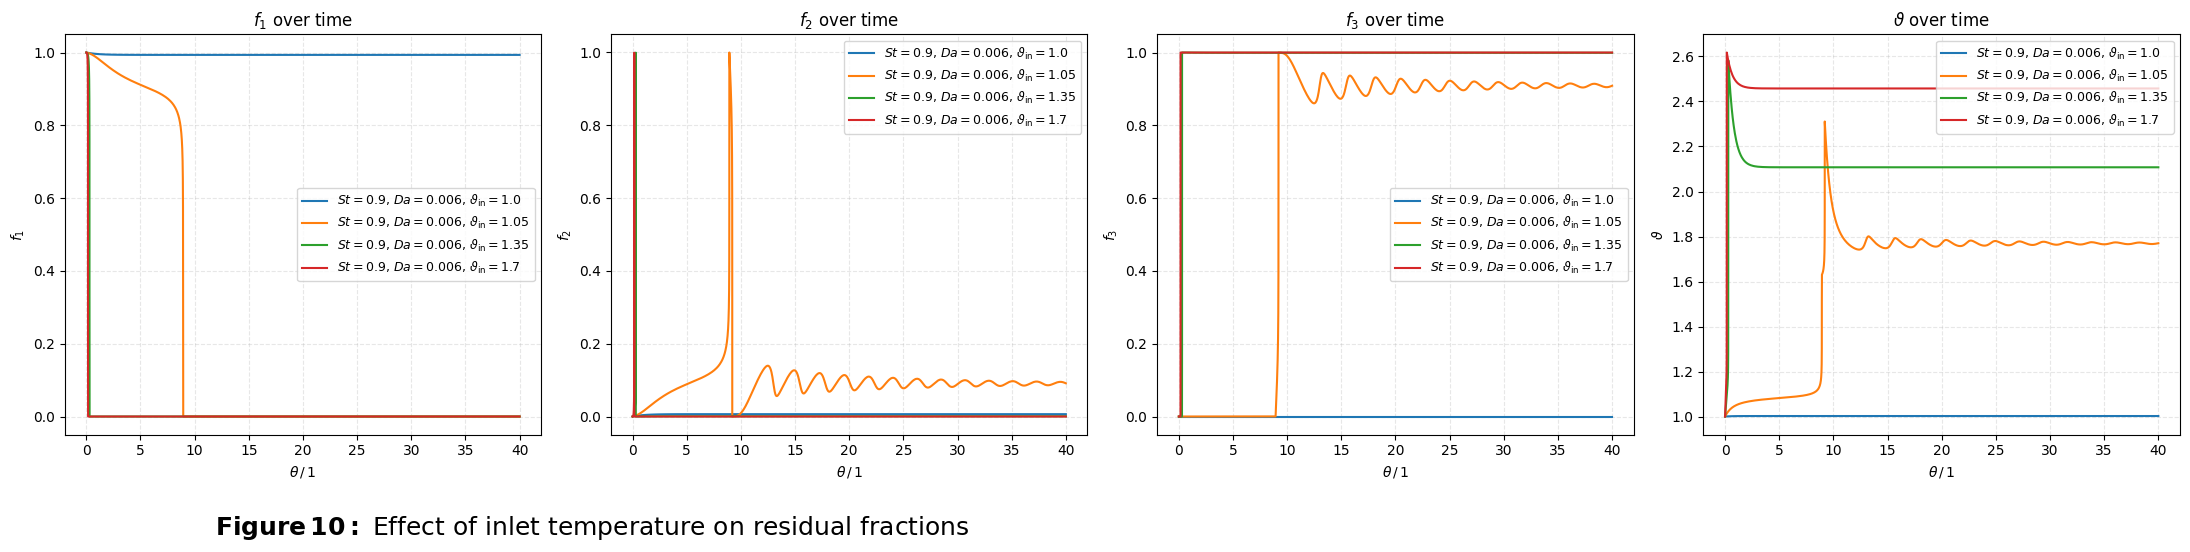

In [22]:
t_span = ([0, 40])                                                   # define new time period for evaluation, dimensionless

simulate_CSTR_dynamics(St_list=[0.9], Da_list=[6e-3], theta_in_list=[1.0, 1.05, 1.35, 1.7])  # call simulation function for varied inlet temperature
plt.figtext(0.1, -0.08, r"$\mathbf{Figure\,10:}$ Effect of inlet temperature on residual fractions", wrap=True, ha='left', fontsize=18)
plt.show()                                                           # add caption and show plot

The dynamic simulations in figure 10 reveal how the inlet temperature $\vartheta_{in}$ significantly influences the temporal evolution and final steady state of the CSTR system. At low $\vartheta_{in}$ (e.g. 1.0), the reactor remains cold and conversion is minimal, indicated by a high $f_1$ and nearly zero $f_2$ and $f_3$. Slight increases in $\vartheta_{in}$ (e.g. 1.05) cause the system to "ignite", shifting toward a hot state where conversion proceeds quickly, $f_3$ dominates and temperature rises sharply. At even higher $\vartheta_{in}$ (e.g. 1.35-1.7), the reactor stabilizes directly in this hot regime, bypassing the lower-conversion states.  

### 4.5 Perturbation analysis
The previous results suggest the presence of multiple steady states, as seen in chapter 3. To investigate stability, we now test whether a given steady state is truly attractive under dynamic conditions. Using the following code section, known steady states ($\vartheta_0$) from chapter 3 are slightly perturbed and observations are made whether the system returns to that state (indicating stability) or evolves toward a different equilibrium (unstable or metastable). This analysis helps validating the predicted steady states from the static analysis and identifying operation regions prone to instabilities or thermal runaway.

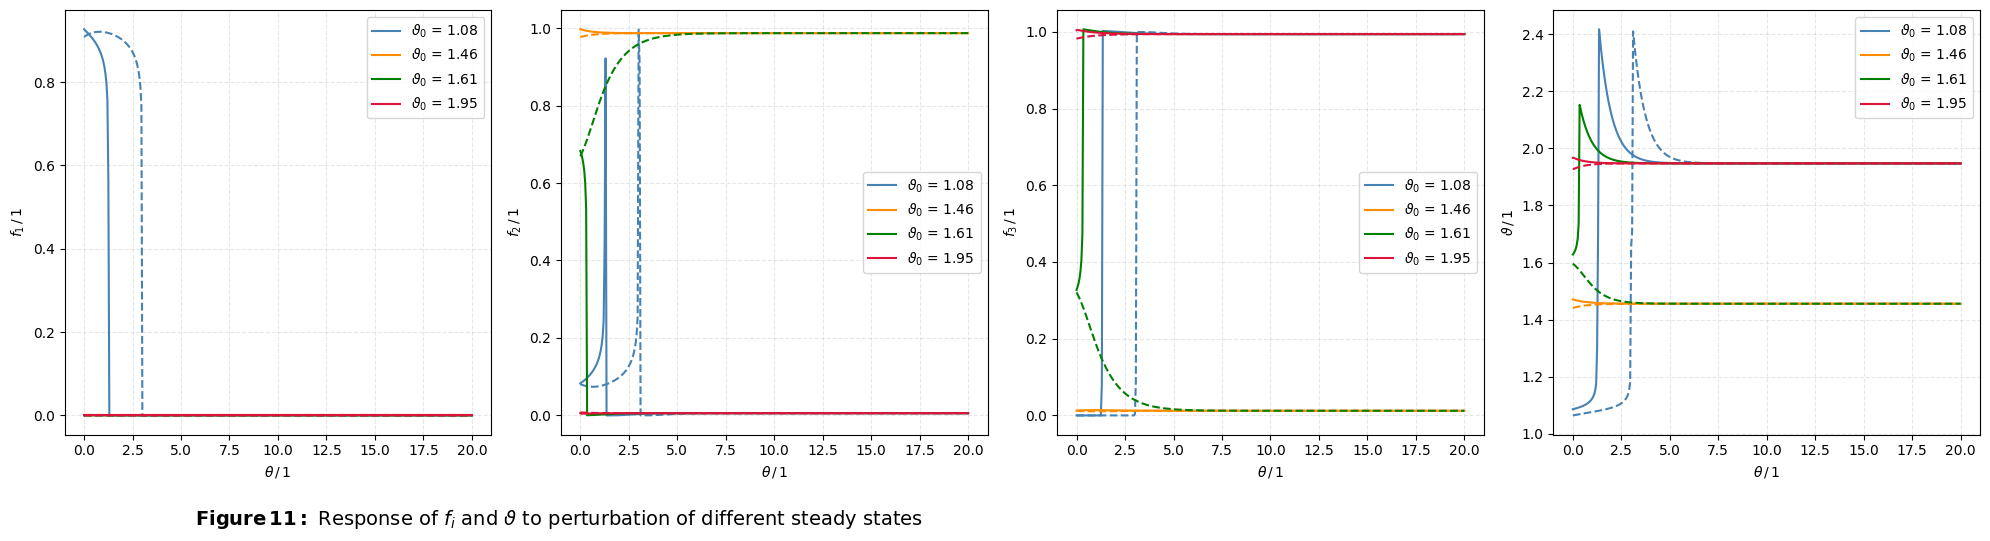

In [23]:
def simulate_perturbition_dynamics(steady_states, perturbation_factor=0.01, St_val=0.6, Da_val=0.006, theta_c_val=1.05, t_span=(0, 20)):
    '''Simulates the response of the CSTR system to ± perturbitions from multiple stationary points.'''
    
    t_eval = np.linspace(*t_span, 400)                               # get evaluation time from t_span
    fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    labels = [r"$f_1\,/\,1$", r"$f_2\,/\,1$", r"$f_3\,/\,1$", r"$\vartheta\,/\,1$"]  # axis labels

    for idx, ss in enumerate(steady_states):
        perturbed1 = ss * (1+ perturbation_factor)                    # calculate perturbed value, and solve for that value
        perturbed2 = ss * (1- perturbation_factor) 
        sol1 = solve_ivp(lambda t, f: dyn_CSTR_balance(t, f, St_val, Da_val, theta_c_val),
                        t_span, y0=perturbed1, t_eval=t_eval, method='BDF', rtol=1e-6, atol=1e-9)
        sol2 = solve_ivp(lambda t, f: dyn_CSTR_balance(t, f, St_val, Da_val, theta_c_val),
                        t_span, y0=perturbed2, t_eval=t_eval, method='BDF', rtol=1e-6, atol=1e-9)
       
        for i in range(3):                                           # plot f_1, f_2, f_3
            axs[i].plot(sol1.t, sol1.y[i], linestyle='-', color=color[idx], label=fr"$\vartheta_0$ = {ss[3]:.2f}")
            axs[i].plot(sol2.t, sol2.y[i], linestyle='--', color=color[idx])
        axs[3].plot(sol1.t, sol1.y[3], linestyle='-', color=color[idx],label=fr"$\vartheta_0$ = {ss[3]:.2f}")
        axs[3].plot(sol2.t, sol2.y[3], linestyle='--', color=color[idx])
        
    for i in range(4):
        axs[i].set_xlabel(r"$\theta\,/\,1$")                         # set x labels
        axs[i].set_ylabel(labels[i])                                 # set y labels
        axs[i].legend()                                              # add legend
        axs[i].grid(True, linestyle='--', alpha=0.3)                 # add grid
        
    plt.figtext(0.1, -0.06, r"$\mathbf{Figure\,11:}$ Response of $f_i$ and $\vartheta$ to perturbation of different steady states",wrap=True, horizontalalignment="left", fontsize=14) # add caption
    plt.tight_layout()
    plt.show()

steady_states = [                                                    # define steady states found in static analysis (chapter 3)
    np.array([9.17599526e-01, 8.17850593e-02, 1.58148563e-09, 1.07536883e+00]),
    np.array([9.71410960e-04, 9.86901880e-01, 1.21267086e-02, 1.45567479e+00]),
    np.array([7.47957424e-05, 6.75859253e-01, 3.24065951e-01, 1.61200306e+00]),
    np.array([1.22719837e-06, 5.84366745e-03, 9.94155105e-01, 1.94707706e+00])
]
simulate_perturbition_dynamics(steady_states, perturbation_factor=+0.01)

For the perturbation analysis, starting from $\vartheta_0 = 1.08$, the system does not remain near the initial point but overshoots the intermediate steady state and eventually settles at the highest stable steady state around $\vartheta \approx 1.95$. Starting from $\vartheta_0 = 1.46$ and $\vartheta_0 = 1.95$, the system remains stable at those respective points, confirming their stability. The initial point at $\vartheta_0 = 1.61$ shows for a positive perturbation a movement toward $\vartheta \approx 1.95 $ and for a negative one a settlement at $\vartheta \approx 1.46$, corresponding to a instable or metastable behavior.  
These results are largely consitent with the steady-state analysis, which identified stable points at $\vartheta \approx 1.08$, $1,46$ and $1.95$. That the metastable point at $\vartheta = 1.08$ was not found, can be explained with the insufficiant cooling (low $St$) and therefore a large enough temperature gradient to overshoot both the lowest metastable as well as the intermediate stable point. The large temperature gradient can be found in the plot hiding behind the large overshooting peaks in temperature and $f_2$ before slowly setteling in the final steady state conditions.

## 5 Sensitivity to kinetic parameters
In the previous chapters, our analyzis focussed on the influence of adjustable operating conditions, which can be deliberately chosen to optimize reactor performance and stability. To also assess the reaction-specific parameters such as the Prater and Arrhenius number, which reflect intrinsic properties of the chemical reactions, we now alter the those. This helps understanding the dependence of the system on the underlying reaction kinetics.
### 5.1 Variation of the Prater numbers
In this section, the influence of the ratio between the Prater numbers of the two consecutive reactions on the reactor behavior is studied. Changes in $\beta_1/\beta_2$ affect the heat release of each reaction step and thus shift the position and stability of the steady states.

In [24]:
beta_var = np.array([                                  # Define varying β1/β2 ratios, keeping β1+β2 constant
    [np.sum(beta)*0.25, np.sum(beta)*0.75],
    [np.sum(beta)*0.50, np.sum(beta)*0.50],
    [np.sum(beta)*0.75, np.sum(beta)*0.25],
    [beta[0], beta[1]]])

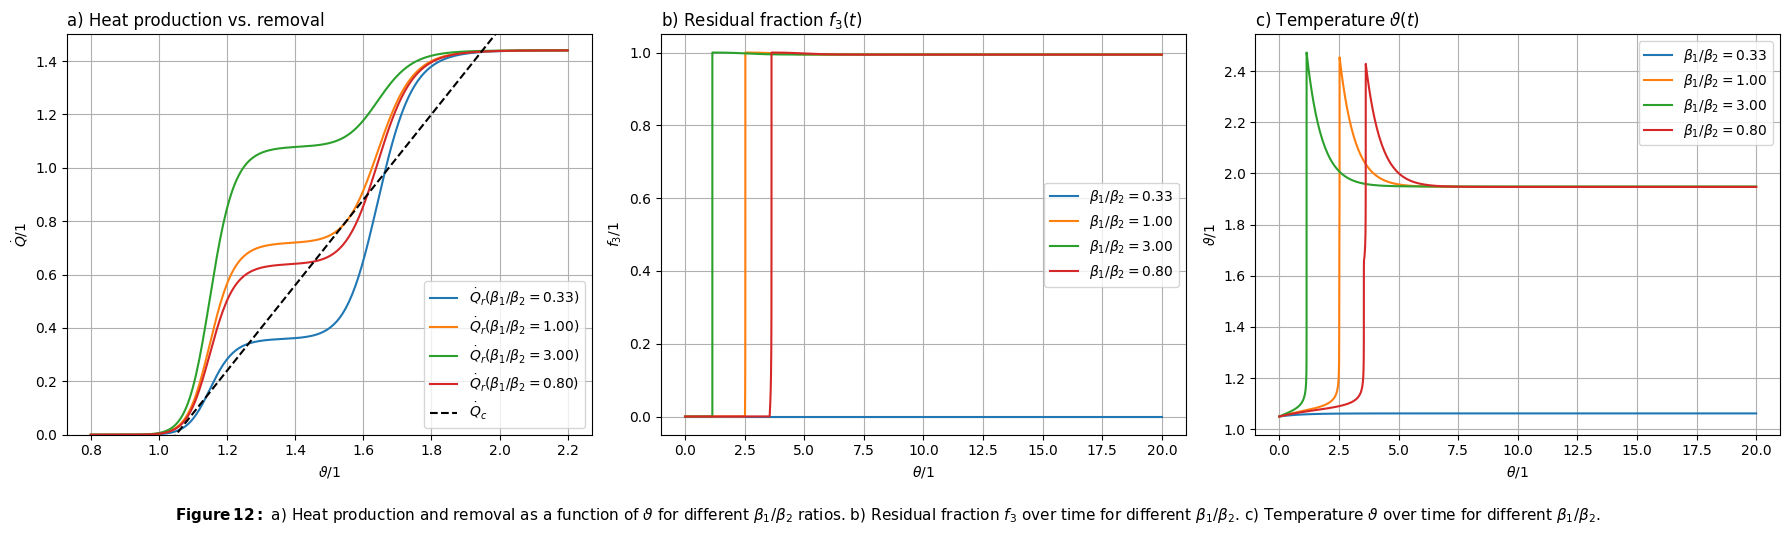

In [26]:
fig, axs = plt.subplots(1, 3, figsize=(18,5))                        # prepare plot
labels = [r"a) Heat production vs. removal", r"b) Residual fraction $f_3(t)$", r"c) Temperature $\vartheta(t)$"]

Q_c_line = (1 + St[2]) * (theta - theta_c[2])                        # calculate heat removal

for i, (b1, b2) in enumerate(beta_var):                              # loop over beta values
    Q_r_tmp = np.zeros_like(theta)
    for j, T in enumerate(theta):                                    # loop for values needed to calculate Q_r 
        k1 = rxn_k(T, gamma[0], gamma)[0]
        k2 = rxn_k(T, gamma[0], gamma)[1]
        Da_theta_1 = Da[0] * k1
        Da_theta_2 = Da[0] * k2
        Q_r_tmp[j] = b1 * Da_theta_1 / (1 + Da_theta_1) + b2 * Da_theta_2 / (1 + Da_theta_2) # calculate Q_r
    label_str = fr"$\dot{{Q}}_r (\beta_1/\beta_2 = {(b1/b2):.2f})$"  # get label string for plot a)
    axs[0].plot(theta, Q_r_tmp, label=label_str)                     # plot Q_r over temperature

    def CSTR_balance_beta(t, f):                                     
        '''balance equations to solve for given beta values: compare to "dyn_CSTR_balance()" function for more information          '''
        w = rxn_w(f, gamma[0], gamma)                                
        w_1, w_2 = w[0], w[1]
        dfdt = np.zeros(4)
        dfdt[0] = f_in[0] - f[0] - Da[0] * w_1
        dfdt[1] = f_in[1] - f[1] + Da[0] * (w_1 - w_2)
        dfdt[2] = f_in[2] - f[2] + Da[0] * w_2
        dfdt[3] = (1 + St[2]) * (theta_c[2] - f[3]) + Da[0] * (b1 * w_1 + b2 * w_2)
        return dfdt
                                                                     # solve balance equations
    sol = solve_ivp(CSTR_balance_beta, [0, 20], np.append(f_in[:3], theta_c[2]), method='BDF', rtol=1e-6, atol=1e-9)

    axs[1].plot(sol.t, sol.y[2], label=fr"$\beta_1/\beta_2 = {(b1/b2):.2f}$")  # plot b) 
    axs[2].plot(sol.t, sol.y[3], label=fr"$\beta_1/\beta_2 = {(b1/b2):.2f}$")    # plot c)

# plot adjustment (labeling, grid, legends, title)
axs[0].plot(theta, Q_c_line, 'k--', label=r"$\dot{Q}_c$")
axs[0].set(xlabel=r"$\vartheta/1$", ylabel=r"$\dot{Q}/1$", ylim=(0, 1.5))
axs[1].set(xlabel=r"$\theta/1$", ylabel=r"$f_3/1$")
axs[2].set(xlabel=r"$\theta/1$", ylabel=r"$\vartheta/1$")

for ax in range(3):
    axs[ax].set_title(labels[ax], loc='left', fontsize=12)
    axs[ax].legend(loc='best')
    axs[ax].grid(True)

plt.tight_layout()
plt.figtext(0.1, -0.05, r"$\mathbf{Figure\,12:}$ a) Heat production and removal as a function of $\vartheta$ for different $\beta_1/\beta_2$ ratios. "
    r"b) Residual fraction $f_3$ over time for different $\beta_1/\beta_2$. "
    r"c) Temperature $\vartheta$ over time for different $\beta_1/\beta_2$.",
    wrap=True, horizontalalignment="left", fontsize=11)
plt.show()

As seen in figure 12, varying the ratio of the Prater numbers strongly affects the steady-state and the dynamic behavior of the CSTR. When $\beta_1$ is reduced (blue curve) the system remains at the inlet temperature without significant reaction, trapped in the low-temperature steady state. Because of the low exothermicity of reaction 1 (lower $\beta_1$) in this case, the temperature rise is insufficiant to kick of the reaction. In all other cases the system reaches full conversion to $A_3$ and settles at the highest stable steady state at $\vartheta \approx 1.95$ just like the base scenario ($\beta_1$/$\beta_2$ = 0.64/0.80, red curve). Due to the higher $\beta_1$, the $\dot{Q_r}$ curve rises more steeply at lower temperatures, eliminating stable intermediate steady-state intersections. Therefore the system directly moves to the high temperature steady-state, driven by the high exothermicity of reaction 1.
### 5.2 Variation of the Arrhenius numbers
Here, the effect of varying the ratio of the Arrhenius numbers of the two reactions is analyzed. Since these parameters govern the temperature sensitivity of the rate constants, changing $\gamma_1/\gamma_2$ alters the shape of the heat release curve and the resulting steady state behavior.

In [27]:
gamma_var = np.array([                                 # Define varying gamma ratios, keeping the sum constant
    [np.sum(gamma)*0.4,np.sum(gamma)*0.6],
    [np.sum(gamma)*0.5,np.sum(gamma)*0.5],
    [np.sum(gamma)*0.6,np.sum(gamma)*0.4],
    [gamma[0], gamma[1]]])

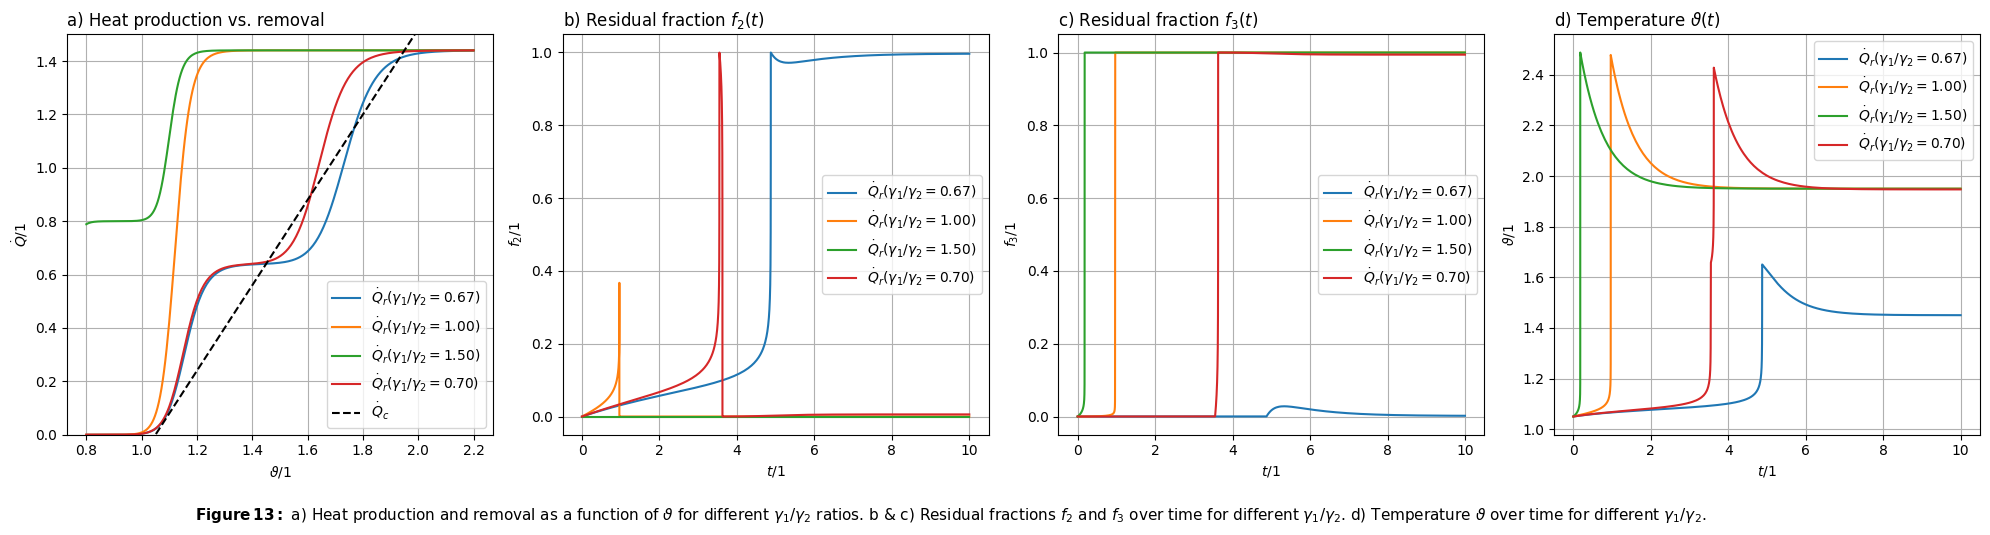

In [28]:
fig, axs = plt.subplots(1, 4, figsize=(20,5))                        # prepare plot
labels = [r"a) Heat production vs. removal", r"b) Residual fraction $f_2(t)$", r"c) Residual fraction $f_3(t)$", r"d) Temperature $\vartheta(t)$"]

Q_c_line = (1 + St[2]) * (theta - theta_c[2])                        # calculate heat removal

for i, (g1, g2) in enumerate(gamma_var):                             # loop over gamma values
    Q_r_tmp = np.zeros_like(theta)
    for j, T in enumerate(theta):                                    # loop to calculate Q_r 
        k1 = rxn_k(T, g1, [g1, g2])[0]
        k2 = rxn_k(T, g1, [g1, g2])[1]
        Da_theta_1 = Da[0] * k1
        Da_theta_2 = Da[0] * k2
        Q_r_tmp[j] = beta[0] * Da_theta_1 / (1 + Da_theta_1) + beta[1] * Da_theta_2 / (1 + Da_theta_2)

    label_str = fr"$\dot{{Q}}_r(\gamma_1/\gamma_2= {(g1/g2):.2f})$"  # get label string for plot a)
    axs[0].plot(theta, Q_r_tmp, label=label_str)                     # plot Q_r over temperature

    def CSTR_balance_gamma(t, f):                                    
        '''Balance equations to solve for given gamma values: compare to "dyn_CSTR_balance()" function for more information'''
        w = rxn_w(f, g1, [g1, g2])                              
        w_1, w_2 = w[0], w[1]
        dfdt = np.zeros(4)
        dfdt[0] = f_in[0] - f[0] - Da[0] * w_1
        dfdt[1] = f_in[1] - f[1] + Da[0] * (w_1 - w_2)
        dfdt[2] = f_in[2] - f[2] + Da[0] * w_2
        dfdt[3] = (1 + St[2]) * (theta_c[2] - f[3]) + Da[0] * (beta[0] * w_1 + beta[1] * w_2)
        return dfdt

    sol = solve_ivp(CSTR_balance_gamma, [0, 10], np.append(f_in[:3], theta_c[2]), method='BDF', rtol=1e-6, atol=1e-9)

    axs[1].plot(sol.t, sol.y[1], label=label_str)                    # plot f2(t)
    axs[2].plot(sol.t, sol.y[2], label=label_str)                    # plot f3(t)
    axs[3].plot(sol.t, sol.y[3], label=label_str)                    # plot theta(t)

# plot adjustment (labeling, grid, legends, title)
axs[0].plot(theta, Q_c_line, 'k--', label=r"$\dot{Q}_c$")
axs[0].set(xlabel=r"$\vartheta/1$", ylabel=r"$\dot{Q}/1$", ylim=(0, 1.5))
axs[1].set(xlabel=r"$t/1$", ylabel=r"$f_2/1$")
axs[2].set(xlabel=r"$t/1$", ylabel=r"$f_3/1$")
axs[3].set(xlabel=r"$t/1$", ylabel=r"$\vartheta/1$")

for ax in range(4):
    axs[ax].set_title(labels[ax], loc='left', fontsize=12)
    axs[ax].legend(loc='best')
    axs[ax].grid(True)

plt.tight_layout()
plt.figtext(0.1, -0.05, r"$\mathbf{Figure\,13:}$ a) Heat production and removal as a function of $\vartheta$ for different $\gamma_1/\gamma_2$ ratios. "
    r"b & c) Residual fractions $f_2$ and $f_3$ over time for different $\gamma_1/\gamma_2$. "
    r"d) Temperature $\vartheta$ over time for different $\gamma_1/\gamma_2$.",
    wrap=True, horizontalalignment="left", fontsize=11)
plt.show()

When varying the Arrhenius number ratio $\gamma_1$/$\gamma_2$, the results show that for a ratio of 0.67 the system stabilizes at the intermediate steady state around $\vartheta \approx 1.45$, with a high residual fraction of $A_2$ and essentially no production of $A_3$. This suggests that the reduces activation barrier for reaction 1 favors the intermediate $A_2$ and prevents significant conversion to $A_3$, as reaction 2 is kinetically suppressed at the accessible temperatures.  
In contrast, for all other ratios including the base scenario (red curve), the system evolves towards the upper stable steady state with high $f_3$, as reaction 2 becomes sufficiently fast to fully convert $A_2$ to $A_3$. For $\gamma_1$/$gamma_2$ = 1, only a single S-shaped curve is observed instead of a double-S. This reflects the balaned activation energies of both reactions, which eliminates the intermediate steady state and leads directly to the high-temperature branch. The observation that the $\dot{Q_r}$ curve for a $\gamma_1$/$gamma_2$ = 1.5 already starts around $\dot{Q_r} \approx 0.8$ reflects the strong temperature sensitivity of reaction 2. The higher activation energy of reaction 1 shifts the $\dot{Q_r}$ curve upward, favoring direct transition to the upper steady state with high $f_3$.

## 6 Conclusion
This study demonstrated that the behavior of a polytropic CSTR with a first-order consecutive reaction network is strongly governed by thermokinetic parameters. By systematically varying dimensionless groups such as the effective cooling temperature, Stanton number, Damköhler number and the inlet temperature, which interactively define the thermal stability and selectivity of products, we analyzed both steady-state multiplicity and dynamic stability of the reactor.  

The results show that the position of the steady-state temperature is largely influenced by the effective cooling temperature in changing the heat removing ability. Reduced effective cooling temperature causes the curve of heat removal to shift upwards (higher intercept) and thus the reactor stabilized at a lower temperature. This inhibits the process of converting intermediate into product $A_3$ so it is best if the target species is $A_2$ as it would lead to the accumulation of $A_2$. Operation parameters resulting in a high residual fraction $f_2$ are e.g.: $St=1.0$, $Da=0.006$ and $\vartheta_{in}=1.05$. An increased effective cooling temperature, conversely, compacts the temperature profile to enable the system to access high temperature regimes where the second reaction step is increased, hence driving conversion towards $A_3$. But this also presents more danger of the thermal runaway or oscillatory instability.

The preheating temperature determines the path followed by the reactor to startup and thus exerts a measurable influence on determining which steady-state eventually comes to be occupied by the system. Since the reactor performs a large number of steady-states, the early determination of the temperature is a kind of selection of one of the states. The increased temperatures of the preheating were demonstrated to allow the access to high-temperature stable regime that is associated with the maximized conversion to $A_3$. On the other hand, inefficient preheating keeps the system at low conversion regimes.

The Stanton number which is a sum up of relative cooling intensity alters the slope of the heat removal line. Greater Stanton numbers raise the rate of cooling which tends to bring the system to lower temperature operating points. This conduct is similar to the behavior of effective cooling temperature except that in the case of the effective cooling temperature the impact is more felt in the dynamics of adjusting the feedback loop of temperature elevation to thermodynamic heat escaping. All these parameters settle the gradient and contact with the heat generation line, which settle the fixed points of action of the reactor.

The Damköhler number, which represents the ratio of the residence and reaction time is also important in deciding the overall conversion levels. An increased Damkoher number prolongs the dwell time of the reactants in the reactor that leads to more conversion chain and a better production of $A_3$ . Nonetheless, when such value is excessively high and there is poor heat removal design there can be an unstable or oscillatory behavior in a reactor.

Lastly, our kinetic parameter studies showed the critical role of reaction-specific parameters such as the Arrhenius and Prater numbers in determining the reactors behavior. Varying the Arrhenius number ratio alters the kinetic dominance between reactions, leading to significant shifts in the location and number of steady states. Similarly, changes in the Prater number influence the thermal feedback, affecting whether the system can transition to high-temperature conversion regimes.  

In summary, the combined steady-state and dynamic analyses underscore the importance of understanding the thermal feedback mechanisms in CSTRs. Such insights are critical for designing safe and efficient reactors, particulary when handeling strongly exothermic and multi-step reactions. Notably, the reactor could overshoot intermediate (meta-)stable states and transition to high-temperature equilibria, emphasizing the need for careful control to avoid unsafe operation points. Moreover, depending on the educts and the desired product, the operation conditions should be reliably chosen to influence the residual concentrations while maintaining stable and secure reactor conditions. 

## 7. References

[1] Stoessel, F. (2008). Thermal safety of chemical processes: Risk assessment and process design (2nd ed., Chapter 5: General Aspects of Reactor Safety, p. 181). Wiley-VCH. Retrieved from https://elmoukrie.com/wp-content/uploads/2022/06/francis-stoessel-thermal-safety-of-chemical-processes_-risk-assessment-and-process-design-wileye28090vch-verlag-gmbh-co.-kgaa-2020.pdf

[2] Levenspiel, O. (1999). Chemical reaction engineering (3rd ed., Chapter 3: Rate Laws and Stoichiometry, p. 54). John Wiley & Sons. Retrieved from https://www.scribd.com/document/396917433/p01

[3] Froment, G. F., Bischoff, K. B., & De Wilde, J. (2010). Chemical reactor analysis and design (3rd ed., Chapter 1: Introduction to Reactor Design, Section 1.3.2 – Consecutive Reactions, p. 19). John Wiley & Sons. Retrieved from https://www.academia.edu/120646380/Chemical_Reactor_Analysis_and_Design_Froment_G_F_Bischoff_K_B

[4] Fogler, H. S. (2016). Elements of chemical reaction engineering (5th ed., Chapter 1.4.1: Continuous-Stirred Tank Reactor, p. 12–14). Pearson. Retrieved from https://ptgmedia.pearsoncmg.com/images/9780133887518/samplepages/9780133887518.pdf  
  
[5] R. Güttel, T. Turek. Chemische Reaktionstechnik. Springer Spektrum, (2021)